# Penelitian Ulasan Batik: LDA + EFM
Notebook ini mengganti BERTopic dengan **Latent Dirichlet Allocation (LDA)** untuk pemodelan topik, kemudian dilanjutkan ke tahap **Explicit Factor Model (EFM)** yang sama seperti sebelumnya.

In [63]:
# ============================================================
# CELL 1: Install library yang diperlukan
# ============================================================
!pip install openpyxl Sastrawi nltk wordcloud matplotlib seaborn pandas numpy scikit-learn pyLDAvis

In [64]:
# ============================================================
# CELL 2: Import library utama
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from wordcloud import WordCloud
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer

print('✅ Semua library berhasil di-import!')

✅ Semua library berhasil di-import!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [65]:
# ============================================================
# CELL 3: Load dataset
# ============================================================
import os

possible_paths = [
    'Book3.xlsx',
    '/content/Book3.xlsx',
    '/mnt/user-data/uploads/Book3.xlsx',
]

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_excel(path)
        print(f'✅ File ditemukan: {path}')
        break

if df is None:
    raise FileNotFoundError('Book3.xlsx tidak ditemukan!')

print(f'Jumlah baris   : {df.shape[0]:,}')
print(f'Jumlah kolom   : {df.shape[1]}')
print(f'Nama kolom     : {list(df.columns)}')
print(f'Distribusi Rating:')
print(df['Rating'].value_counts().sort_index().to_string())

✅ File ditemukan: Book3.xlsx
Jumlah baris   : 5,407
Jumlah kolom   : 10
Nama kolom     : ['User Id', 'User Name', 'Comment', 'Rating', 'Detail Rating', 'Bought Products', 'Product Id', 'Product Name', 'Shop Id', 'Region']
Distribusi Rating:
Rating
1     591
2     615
3     936
4    1192
5    2073


In [66]:
df.head()

,User Id,User Name,Comment,Rating,Detail Rating,Bought Products,Product Id,Product Name,Shop Id,Region
0,239772482,l*****e,Desain:bagus\nBahan:cukup berkualitas\nKenyama...,4,product_quality: 4\nseller_service: 5\ndeliver...,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,ID
1,818084703,m*****5,Desain:keren dan moderen\nBahan:bagus\nTekstur...,4,product_quality: 4\nseller_service: 4\ndeliver...,Batik Indonesia Motif Abimata Kemeja Batik Sli...,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,ID
2,227253735,ari.irawan,Desain:batik dg desain yg bagus\nBahan:halus d...,4,product_quality: 4,Batik Indonesia Motif Abimata Kemeja Batik Sli...,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,ID
3,1316081004,garasibarbersop,Desain:bagus\nBahan:lmbut\nKenyamanan:passs di...,4,product_quality: 4,Batik Indonesia Motif Abimata Kemeja Batik Sli...,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,ID
4,311327546,b*****1,Desain:motif mewah dan hidup\nBahan:kualitas s...,4,product_quality: 4\nseller_service: 5\ndeliver...,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,ID


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5407 entries, 0 to 5406
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User Id          5407 non-null   int64 
 1   User Name        5345 non-null   object
 2   Comment          4567 non-null   object
 3   Rating           5407 non-null   int64 
 4   Detail Rating    5407 non-null   object
 5   Bought Products  5407 non-null   object
 6   Product Id       5407 non-null   int64 
 7   Product Name     5407 non-null   object
 8   Shop Id          5407 non-null   int64 
 9   Region           5400 non-null   object
dtypes: int64(4), object(6)
memory usage: 422.6+ KB


In [68]:
df.describe(include='all')

,User Id,User Name,Comment,Rating,Detail Rating,Bought Products,Product Id,Product Name,Shop Id,Region
count,5.407000e+03,5345,4567,5407.000000,5407,5407,5.407000e+03,5407,5.407000e+03,5400
unique,NaN,4338,4347,NaN,282,2691,NaN,115,NaN,1
top,NaN,a*****a,Bahan:tipis,NaN,product_quality: 5\nseller_service: 5\ndeliver...,Atasan batik modern lengan panjang kimono full...,NaN,ATASAN BLOUSE BATIK LENGAN BALON UKURAN (M L X...,NaN,ID
freq,NaN,38,12,NaN,905,71,NaN,120,NaN,5400
mean,6.653118e+08,NaN,NaN,3.654892,NaN,NaN,2.142800e+10,NaN,4.707738e+08,NaN
std,8.412203e+08,NaN,NaN,1.369832,NaN,NaN,1.320556e+10,NaN,4.644124e+08,NaN
min,1.149550e+05,NaN,NaN,1.000000,NaN,NaN,5.494744e+08,NaN,1.807740e+05,NaN
25%,1.461338e+08,NaN,NaN,3.000000,NaN,NaN,9.313848e+09,NaN,6.461113e+07,NaN
50%,4.159442e+08,NaN,NaN,4.000000,NaN,NaN,2.304942e+10,NaN,2.564890e+08,NaN
75%,1.037670e+09,NaN,NaN,5.000000,NaN,NaN,2.777472e+10,NaN,1.085538e+09,NaN


# 4.3 EDA — Exploratory Data Analysis

## 4.3.1 Distribusi Rating

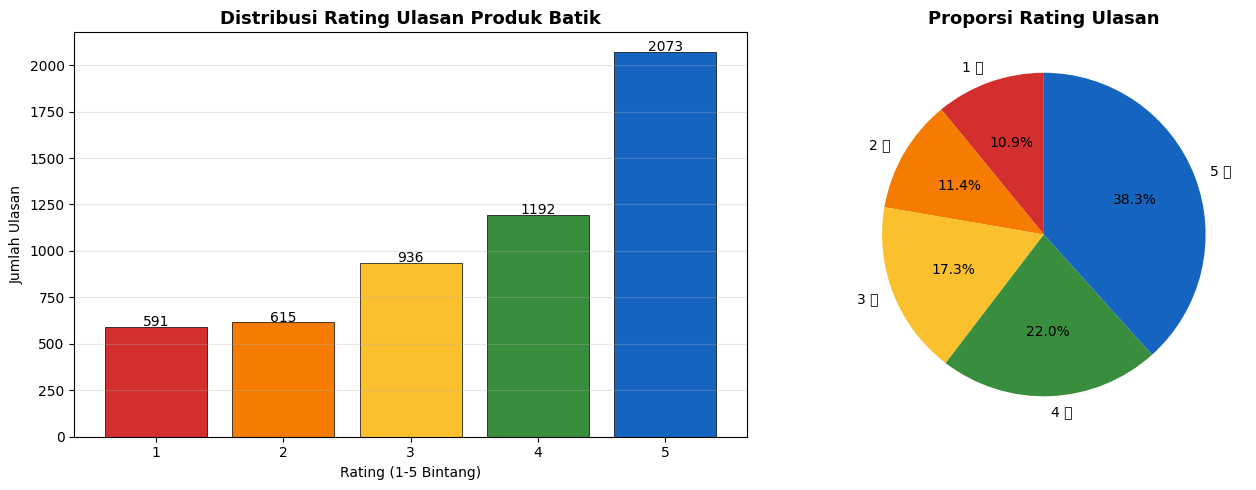

Rating
1     591
2     615
3     936
4    1192
5    2073
Name: count, dtype: int64


In [69]:
rating_counts = df['Rating'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#d32f2f', '#f57c00', '#fbc02d', '#388e3c', '#1565c0']
axes[0].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribusi Rating Ulasan Produk Batik', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating (1-5 Bintang)')
axes[0].set_ylabel('Jumlah Ulasan')
for i, v in enumerate(rating_counts.values):
    axes[0].text(rating_counts.index[i], v + 5, str(v), ha='center', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(rating_counts.values, labels=[f'{r} ⭐' for r in rating_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporsi Rating Ulasan', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print(rating_counts)

## 4.3.2 Analisis Missing Value

In [70]:
print('=== Missing Values per Kolom ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal ulasan kosong (Comment NaN): {df["Comment"].isnull().sum()}')
print(f'Total ulasan string kosong     : {(df["Comment"].astype(str).str.strip() == "").sum()}')

=== Missing Values per Kolom ===
           Missing Count  Missing (%)
User Name             62         1.15
Comment              840        15.54
Region                 7         0.13

Total ulasan kosong (Comment NaN): 840
Total ulasan string kosong     : 0


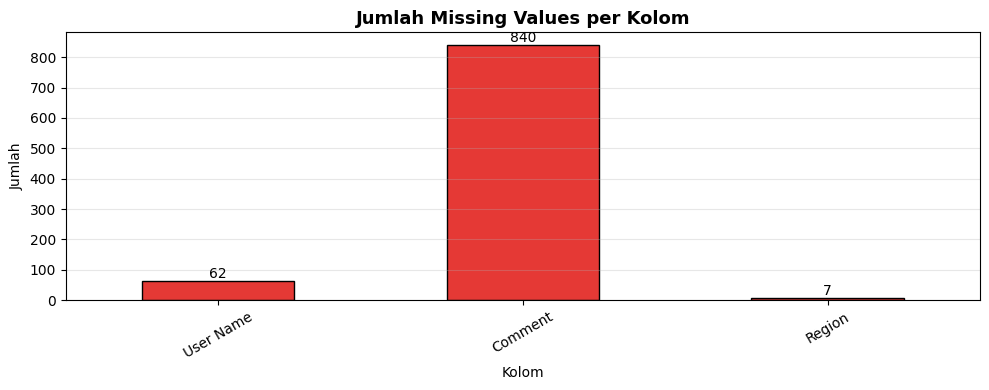

In [71]:
fig, ax = plt.subplots(figsize=(10, 4))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
    missing_plot.plot(kind='bar', color='#e53935', edgecolor='black', ax=ax)
    ax.set_title('Jumlah Missing Values per Kolom', fontsize=13, fontweight='bold')
    ax.set_ylabel('Jumlah')
    ax.set_xlabel('Kolom')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom')
else:
    ax.text(0.5, 0.5, 'Tidak ada missing value!', ha='center', va='center', fontsize=14)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.3.3 Analisis Produk Toko

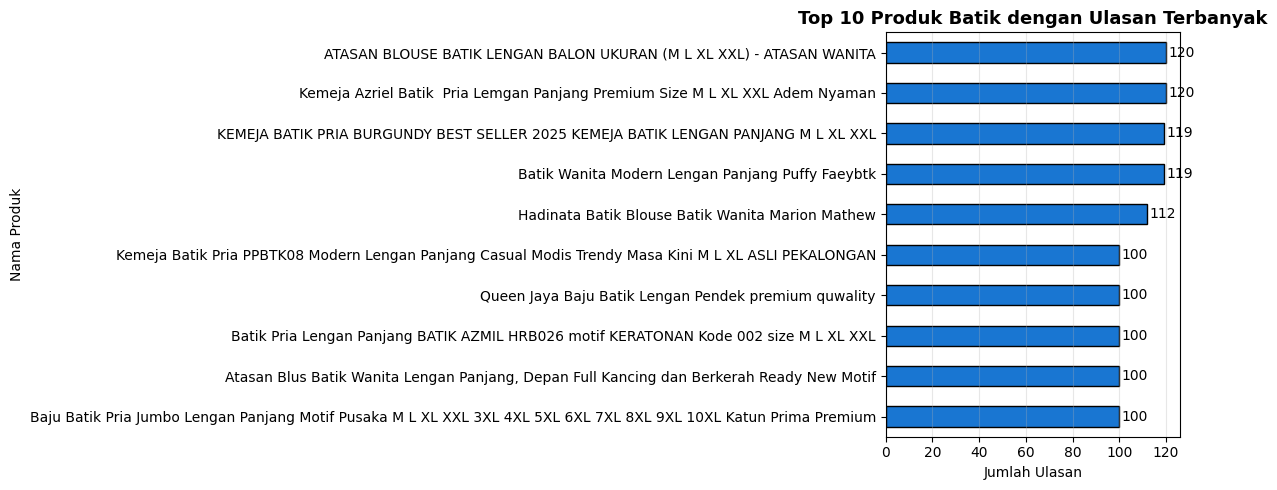

Jumlah produk unik: 115
Jumlah toko unik  : 58


In [72]:
top_products = df['Product Name'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
top_products.plot(kind='barh', color='#1976d2', edgecolor='black', ax=ax)
ax.set_title('Top 10 Produk Batik dengan Ulasan Terbanyak', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Ulasan')
ax.set_ylabel('Nama Produk')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
for p in ax.patches:
    ax.annotate(str(int(p.get_width())), (p.get_width() + 1, p.get_y() + p.get_height()/2),
                va='center')
plt.tight_layout()
plt.savefig('top_produk.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Jumlah produk unik: {df["Product Name"].nunique()}')
print(f'Jumlah toko unik  : {df["Shop Id"].nunique()}')

## 4.3.4 Analisis Panjang Ulasan

=== Statistik Panjang Ulasan ===
       panjang_karakter  jumlah_kata
count           4567.00      4567.00
mean             124.66        17.96
std               92.02        14.24
min                1.00         1.00
25%               66.00         9.00
50%              105.00        15.00
75%              163.00        24.00
max             2346.00       303.00


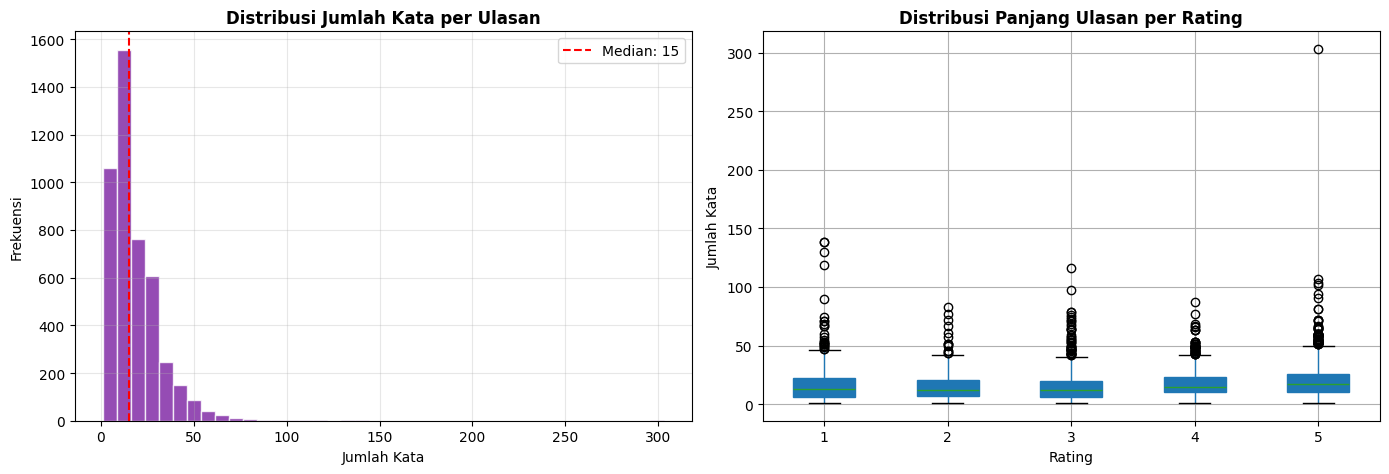

In [73]:
df_ulasan = df[df['Comment'].notna() & (df['Comment'].astype(str).str.strip() != '')].copy()
df_ulasan['comment_str'] = df_ulasan['Comment'].astype(str)
df_ulasan['panjang_karakter'] = df_ulasan['comment_str'].str.len()
df_ulasan['jumlah_kata'] = df_ulasan['comment_str'].str.split().str.len()

print('=== Statistik Panjang Ulasan ===')
print(df_ulasan[['panjang_karakter', 'jumlah_kata']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_ulasan['jumlah_kata'], bins=40, color='#7b1fa2', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi Jumlah Kata per Ulasan', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df_ulasan['jumlah_kata'].median(), color='red', linestyle='--',
                label=f'Median: {df_ulasan["jumlah_kata"].median():.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

df_ulasan.boxplot(column='jumlah_kata', by='Rating', ax=axes[1], patch_artist=True)
axes[1].set_title('Distribusi Panjang Ulasan per Rating', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Jumlah Kata')
plt.suptitle('')

plt.tight_layout()
plt.savefig('panjang_ulasan.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.3.5 Analisis Detail Rating

In [74]:
def parse_detail_rating(detail_str):
    result = {}
    if pd.isna(detail_str):
        return result
    parts = str(detail_str).split()
    i = 0
    while i < len(parts):
        if ':' in parts[i]:
            key = parts[i].replace(':', '')
            if i+1 < len(parts):
                try:
                    result[key] = int(parts[i+1])
                    i += 2
                    continue
                except:
                    pass
        i += 1
    return result

detail_expanded = df['Detail Rating'].apply(parse_detail_rating).apply(pd.Series)
print('Kolom detail rating yang tersedia:')
print(detail_expanded.columns.tolist())
print()
print('Statistik rata-rata per dimensi:')
print(detail_expanded.mean().round(2))

Kolom detail rating yang tersedia:
['product_quality', 'seller_service', 'delivery_service', 'driver_service']

Statistik rata-rata per dimensi:
product_quality     3.66
seller_service      4.55
delivery_service    4.68
driver_service      4.83
dtype: float64


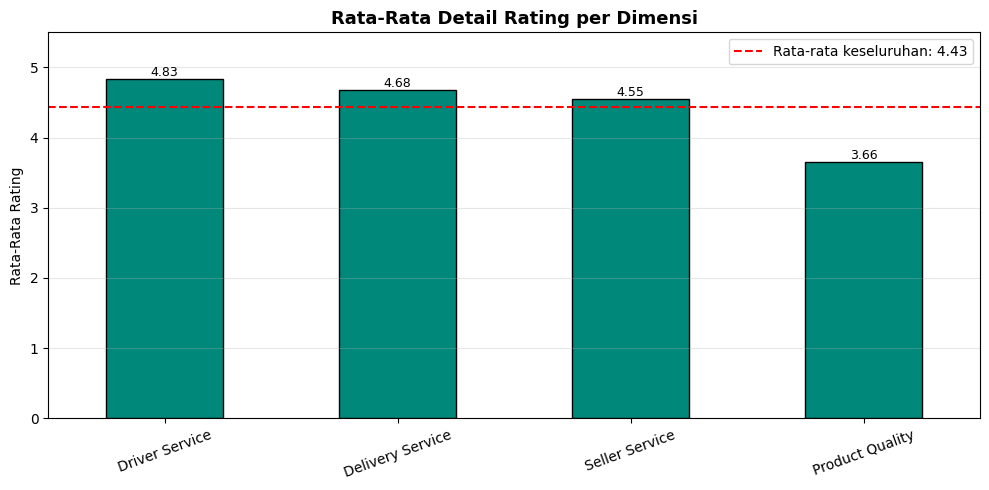

In [75]:
avg_ratings = detail_expanded.mean().dropna().sort_values(ascending=False)
if len(avg_ratings) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    avg_ratings.plot(kind='bar', color='#00897b', edgecolor='black', ax=ax)
    ax.set_title('Rata-Rata Detail Rating per Dimensi', fontsize=13, fontweight='bold')
    ax.set_ylabel('Rata-Rata Rating')
    ax.set_ylim(0, 5.5)
    ax.set_xticklabels([col.replace('_', ' ').title() for col in avg_ratings.index], rotation=20)
    ax.axhline(y=avg_ratings.mean(), color='red', linestyle='--',
               label=f'Rata-rata keseluruhan: {avg_ratings.mean():.2f}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig('detail_rating.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4.3.6 Analisis User Activity

Total user unik     : 5105
Rata-rata ulasan/user: 1.06
Max ulasan 1 user   : 4


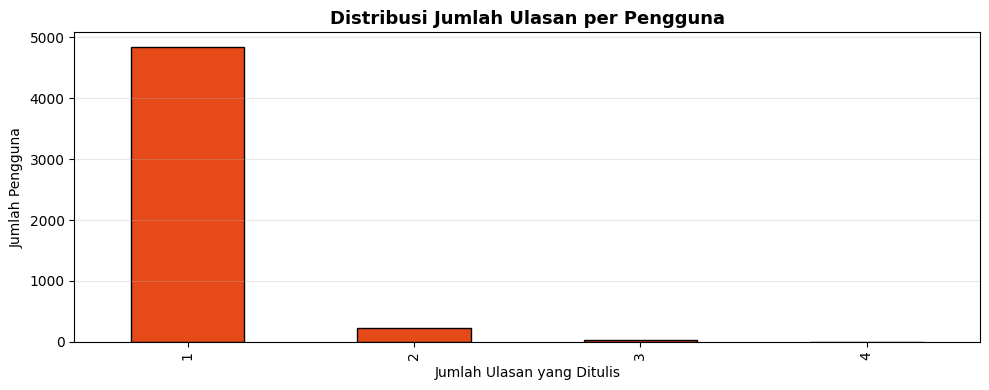

In [76]:
user_counts = df.groupby('User Id').size()
print(f'Total user unik     : {user_counts.shape[0]}')
print(f'Rata-rata ulasan/user: {user_counts.mean():.2f}')
print(f'Max ulasan 1 user   : {user_counts.max()}')

fig, ax = plt.subplots(figsize=(10, 4))
user_activity = user_counts.value_counts().sort_index().head(15)
user_activity.plot(kind='bar', color='#e64a19', edgecolor='black', ax=ax)
ax.set_title('Distribusi Jumlah Ulasan per Pengguna', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Ulasan yang Ditulis')
ax.set_ylabel('Jumlah Pengguna')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('user_activity.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 4.4 Preprocessing Data

1. Data Cleaning
2. Case Folding
3. Noise Removal
4. Normalisasi Kata (slang)
5. Tokenization
6. Stopword Removal
7. Stemming

## 4.4.1 Data Cleaning

In [77]:
print(f'Jumlah data awal         : {len(df)}')

df_clean = df.dropna(subset=['Comment']).copy()
df_clean = df_clean[df_clean['Comment'].astype(str).str.strip() != ''].copy()
print(f'Setelah hapus comment kosong: {len(df_clean)}')

df_clean = df_clean.drop_duplicates(subset=['User Id', 'Comment'])
print(f'Setelah hapus duplikat   : {len(df_clean)}')

df_clean = df_clean.reset_index(drop=True)
df_clean['text'] = df_clean['Comment'].astype(str)
print(f'\nDataset siap diproses: {df_clean.shape}')

Jumlah data awal         : 5407
Setelah hapus comment kosong: 4567
Setelah hapus duplikat   : 4390

Dataset siap diproses: (4390, 11)


## 4.4.2 Case Folding

In [78]:
def case_folding(text):
    return text.lower()

df_clean['text'] = df_clean['text'].apply(case_folding)
print('Contoh sebelum & sesudah Case Folding:')
for i, row in df_clean[['Comment', 'text']].head(3).iterrows():
    print(f'  Asli   : {row["Comment"][:80]}')
    print(f'  Hasil  : {row["text"][:80]}')
    print()

Contoh sebelum & sesudah Case Folding:
  Asli   : Desain:bagus
Bahan:cukup berkualitas
Kenyamanan:ada furing nya

Buat BB 82 dan t
  Hasil  : desain:bagus
bahan:cukup berkualitas
kenyamanan:ada furing nya

buat bb 82 dan t

  Asli   : Desain:keren dan moderen
Bahan:bagus
Tekstur:lembut dan halus

Pengiriman cepat 
  Hasil  : desain:keren dan moderen
bahan:bagus
tekstur:lembut dan halus

pengiriman cepat 

  Asli   : Desain:batik dg desain yg bagus
Bahan:halus dan nyaman
Tekstur:sangat lembut dan
  Hasil  : desain:batik dg desain yg bagus
bahan:halus dan nyaman
tekstur:sangat lembut dan



## 4.4.3 Noise Removal

In [79]:
def noise_removal(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[@#]\S+', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['text'] = df_clean['text'].apply(noise_removal)
print('Contoh setelah Noise Removal:')
for i, row in df_clean[['Comment', 'text']].head(3).iterrows():
    print(f'  Asli  : {str(row["Comment"])[:80]}')
    print(f'  Hasil : {row["text"][:80]}')
    print()

Contoh setelah Noise Removal:
  Asli  : Desain:bagus
Bahan:cukup berkualitas
Kenyamanan:ada furing nya

Buat BB 82 dan t
  Hasil : desain bagus bahan cukup berkualitas kenyamanan ada furing nya buat bb dan tingg

  Asli  : Desain:keren dan moderen
Bahan:bagus
Tekstur:lembut dan halus

Pengiriman cepat 
  Hasil : desain keren dan moderen bahan bagus tekstur lembut dan halus pengiriman cepat d

  Asli  : Desain:batik dg desain yg bagus
Bahan:halus dan nyaman
Tekstur:sangat lembut dan
  Hasil : desain batik dg desain yg bagus bahan halus dan nyaman tekstur sangat lembut dan



## 4.4.4 Normalisasi Kata

In [80]:
kamus_normalisasi = {
    'gak': 'tidak', 'ga': 'tidak', 'ngga': 'tidak', 'nggak': 'tidak',
    'gk': 'tidak', 'tdk': 'tidak', 'tak': 'tidak', 'g': 'tidak',
    'tp': 'tapi', 'tpi': 'tapi', 'ttpi': 'tapi',
    'dg': 'dengan', 'dgn': 'dengan', 'sm': 'sama', 'sama2': 'sama-sama',
    'utk': 'untuk', 'tuk': 'untuk', 'buat': 'untuk',
    'sdh': 'sudah', 'udah': 'sudah', 'ud': 'sudah', 'dah': 'sudah',
    'blm': 'belum', 'blom': 'belum',
    'sy': 'saya', 'ak': 'saya', 'aq': 'saya', 'w': 'saya',
    'krn': 'karena', 'karna': 'karena',
    'yg': 'yang', 'yng': 'yang',
    'mksh': 'terima kasih', 'makasih': 'terima kasih', 'thanks': 'terima kasih',
    'thx': 'terima kasih', 'tks': 'terima kasih', 'ty': 'terima kasih',
    'ok': 'oke', 'okelah': 'oke',
    'bgs': 'bagus', 'bgus': 'bagus',
    'bhn': 'bahan', 'kain': 'bahan',
    'adem': 'sejuk', 'ademm': 'sejuk',
    'rapi': 'rapi', 'rapih': 'rapi',
    'kualitas': 'kualitas', 'kwalitas': 'kualitas',
    'sesuai': 'sesuai', 'sesui': 'sesuai',
    'pesen': 'pesan', 'pesenan': 'pesanan',
    'pengiriman': 'pengiriman', 'delivery': 'pengiriman',
    'fast': 'cepat', 'gercep': 'cepat',
    'seller': 'penjual', 'toko': 'toko',
    'recommended': 'rekomendasi', 'recomend': 'rekomendasi', 'rekomen': 'rekomendasi',
    'mantap': 'bagus', 'mantul': 'bagus', 'mantep': 'bagus',
    'kece': 'bagus', 'keren': 'bagus',
    'puas': 'puas', 'puass': 'puas',
    'real': 'asli', 'realpic': 'foto asli', 'realpict': 'foto asli',
    'slim': 'ramping', 'slimfit': 'ramping',
    'motif': 'motif', 'desain': 'desain', 'design': 'desain',
    'warna': 'warna', 'corak': 'corak',
    'jahitan': 'jahitan', 'jahit': 'jahit',
    'ukuran': 'ukuran', 'size': 'ukuran',
    'pas': 'pas', 'cocok': 'cocok',
    'beli': 'beli', 'order': 'pesan', 'co': 'pesan',
    'packing': 'pengemasan', 'paket': 'paket',
    'sampai': 'tiba', 'nyampe': 'tiba', 'datang': 'tiba',
    'murah': 'murah', 'terjangkau': 'murah',
    'amanah': 'terpercaya',
    'next': 'lagi',
    'kondangan': 'pesta', 'acara': 'acara',
    'premium': 'premium',
    'kancingnya': 'kancing',
    'luntur': 'luntur',
    'awet': 'awet',
}

def normalisasi_kata(text):
    words = text.split()
    result = [kamus_normalisasi.get(word, word) for word in words]
    return ' '.join(result)

df_clean['text'] = df_clean['text'].apply(normalisasi_kata)
print(f'Ukuran kamus normalisasi: {len(kamus_normalisasi)} kata')

Ukuran kamus normalisasi: 104 kata


## 4.4.5 Tokenization

In [81]:
def tokenize(text):
    return text.split()

df_clean['tokens'] = df_clean['text'].apply(tokenize)
print(f'Rata-rata token per ulasan: {df_clean["tokens"].str.len().mean():.1f}')

Rata-rata token per ulasan: 19.6


## 4.4.6 Stopword Removal

In [82]:
sw_factory = StopWordRemoverFactory()
sastrawi_stopwords = set(sw_factory.get_stop_words())

custom_stopwords = {
    'ya', 'yaa', 'yaaa', 'sih', 'lah', 'deh', 'dong', 'nih', 'nah',
    'si', 'ku', 'mu', 'nya', 'kak', 'mas', 'mba', 'mbak', 'pak', 'bu',
    'pokoknya', 'alhamdulillah', 'insyaallah', 'semoga', 'aamiin', 'doa',
    'shopee', 'seller', 'kurir', 'spx', 'jne', 'jnt',
    'foto', 'pic', 'pict', 'gambar',
    'terima kasih', 'makasih',
    'aja', 'doang', 'lagi', 'udah', 'banget', 'bgt',
    'pertama', 'kedua', 'kali', 'x',
    'item', 'barang', 'produk',
    'mah', 'mau',
}

all_stopwords = sastrawi_stopwords | custom_stopwords

def remove_stopwords(tokens):
    return [t for t in tokens if t not in all_stopwords and len(t) > 2]

df_clean['tokens'] = df_clean['tokens'].apply(remove_stopwords)
print(f'Total stopwords: {len(all_stopwords)}')
print(f'Rata-rata token setelah stopword removal: {df_clean["tokens"].str.len().mean():.1f}')

Total stopwords: 173
Rata-rata token setelah stopword removal: 14.2


## 4.4.7 Stemming (Sastrawi)

In [83]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

print('Proses stemming... (mungkin memakan waktu beberapa menit)')
df_clean['tokens_stem'] = df_clean['tokens'].apply(stem_tokens)
print('✅ Stemming selesai!')

df_clean['text_preprocessed'] = df_clean['tokens_stem'].apply(lambda t: ' '.join(t))
print('\nContoh hasil akhir preprocessing:')
for i in range(3):
    print(f'  Asli  : {df_clean["Comment"].iloc[i]}')
    print(f'  Proses: {df_clean["text_preprocessed"].iloc[i]}')
    print()

Proses stemming... (mungkin memakan waktu beberapa menit)
✅ Stemming selesai!

Contoh hasil akhir preprocessing:
  Asli  : Desain:bagus
Bahan:cukup berkualitas
Kenyamanan:ada furing nya

Buat BB 82 dan tinggi 168.. Pas
  Proses: desain bagus bahan cukup kualitas nyaman furing tinggi pas

  Asli  : Desain:keren dan moderen
Bahan:bagus
Tekstur:lembut dan halus

Pengiriman cepat dan Pekingnya rapi
  Proses: desain bagus moderen bahan bagus tekstur lembut halus kirim cepat peking rapi

  Asli  : Desain:batik dg desain yg bagus
Bahan:halus dan nyaman
Tekstur:sangat lembut dan halus

Jos bahanya.... Ukuran M pas TPI perut buncit jdi agak ngepres...  Neks beli yg ukuran L ni... Biar gak kelihatan buncit perutnya .hehe
  Proses: desain batik desain bagus bahan halus nyaman tekstur sangat lembut halus jos bahanya ukur pas perut buncit jdi ngepres neks beli ukur biar lihat buncit perut hehe



## 4.4.8 Rekap Hasil Preprocessing

In [84]:
df_clean['jml_token_awal'] = df_clean['Comment'].astype(str).str.split().str.len()
df_clean['jml_token_akhir'] = df_clean['tokens_stem'].str.len()
df_clean['reduksi_pct'] = ((df_clean['jml_token_awal'] - df_clean['jml_token_akhir']) /
                            df_clean['jml_token_awal'] * 100).round(1)

print('=== Statistik Preprocessing ===')
print(f'Data awal          : {len(df)} baris')
print(f'Data setelah clean : {len(df_clean)} baris')
print(f'Rata-rata token awal  : {df_clean["jml_token_awal"].mean():.1f}')
print(f'Rata-rata token akhir : {df_clean["jml_token_akhir"].mean():.1f}')
print(f'Rata-rata reduksi     : {df_clean["reduksi_pct"].mean():.1f}%')

tabel_hasil = df_clean[['Comment', 'text_preprocessed', 'Rating']].head(10)
tabel_hasil.columns = ['Ulasan Asli', 'Hasil Preprocessing', 'Rating']
tabel_hasil

=== Statistik Preprocessing ===
Data awal          : 5407 baris
Data setelah clean : 4390 baris
Rata-rata token awal  : 17.9
Rata-rata token akhir : 14.2
Rata-rata reduksi     : 11.1%


,Ulasan Asli,Hasil Preprocessing,Rating
0,Desain:bagus\nBahan:cukup berkualitas\nKenyama...,desain bagus bahan cukup kualitas nyaman furin...,4
1,Desain:keren dan moderen\nBahan:bagus\nTekstur...,desain bagus moderen bahan bagus tekstur lembu...,4
2,Desain:batik dg desain yg bagus\nBahan:halus d...,desain batik desain bagus bahan halus nyaman t...,4
3,Desain:bagus\nBahan:lmbut\nKenyamanan:passs di...,desain bagus bahan lmbut nyaman passs dipkainy...,4
4,Desain:motif mewah dan hidup\nBahan:kualitas s...,desain motif mewah hidup bahan kualitas sesuai...,4
5,Desain:menarik\n\nSaya kira warnanya coklat da...,desain tarik kira warna coklat hitam nyata dom...,4
6,Desain:menarik\nBahan:kain nggak tipis\nTekstu...,desain tarik bahan bahan tipis tekstur halus f...,4
7,Jahitan nya rapih tapi bahan nya ini bukan kat...,jahit rapi bahan bukan katun prisma katon micr...,4
8,Desain:bgs sesuai order\nBahan:lembut adem\nKe...,desain bagus sesuai pesan bahan lembut sejuk n...,4
9,Desain:bagus\nKenyamanan:bagus\nKualitas Bahan...,desain bagus nyaman bagus kualitas bahan lumay...,4


# 4.5 Analisis Kata Paling Sering Muncul

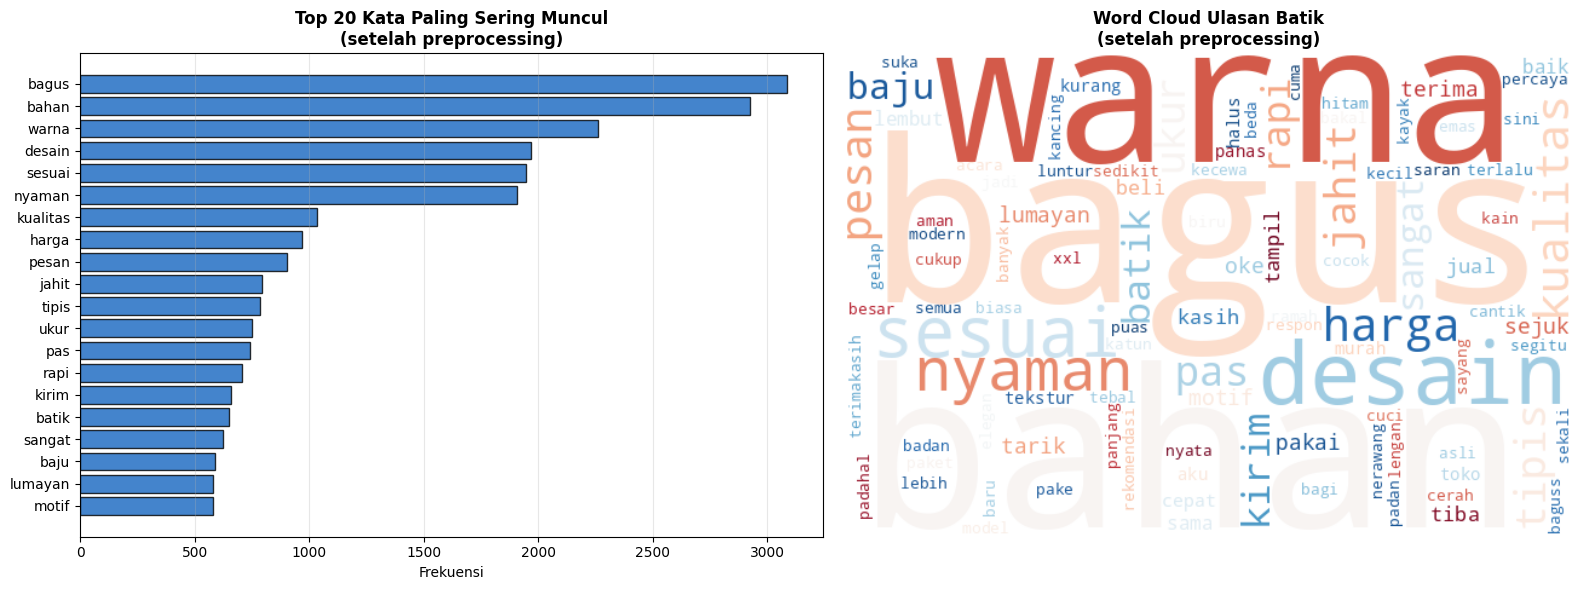

Top 30 kata:
    Kata  Frekuensi
   bagus       3088
   bahan       2924
   warna       2262
  desain       1970
  sesuai       1946
  nyaman       1908
kualitas       1035
   harga        967
   pesan        903
   jahit        796
   tipis        787
    ukur        751
     pas        744
    rapi        706
   kirim        661
   batik        649
  sangat        624
    baju        589
 lumayan        582
   motif        581
     oke        561
   sejuk        549
   pakai        539
   tarik        528
  terima        525
  tampil        491
    tiba        483
   kasih        470
    beli        458
    jual        455


In [85]:
from collections import Counter

all_tokens = [token for tokens in df_clean['tokens_stem'] for token in tokens]
word_freq = Counter(all_tokens)
top_words = pd.DataFrame(word_freq.most_common(30), columns=['Kata', 'Frekuensi'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top20 = top_words.head(20)
axes[0].barh(top20['Kata'][::-1], top20['Frekuensi'][::-1], color='#1565c0', edgecolor='black', alpha=0.8)
axes[0].set_title('Top 20 Kata Paling Sering Muncul\n(setelah preprocessing)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frekuensi')
axes[0].grid(axis='x', alpha=0.3)

wc = WordCloud(width=600, height=400, background_color='white',
               colormap='RdBu', max_words=100, collocations=False)
wc.generate_from_frequencies(word_freq)
axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud Ulasan Batik\n(setelah preprocessing)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('wordcloud_top_kata.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 30 kata:')
print(top_words.to_string(index=False))

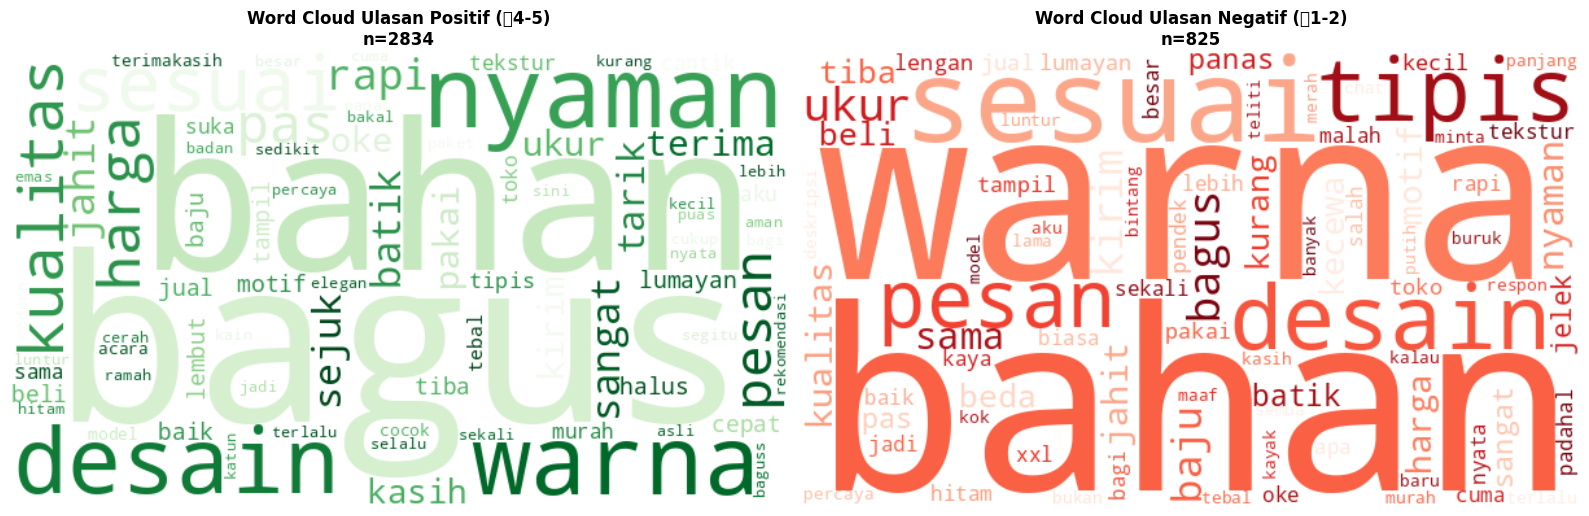

In [86]:
df_positif = df_clean[df_clean['Rating'] >= 4]
df_negatif = df_clean[df_clean['Rating'] <= 2]

tokens_pos = [t for tokens in df_positif['tokens_stem'] for t in tokens]
tokens_neg = [t for tokens in df_negatif['tokens_stem'] for t in tokens]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
if tokens_pos:
    wc_pos = WordCloud(width=600, height=350, background_color='white',
                       colormap='Greens', max_words=80, collocations=False)
    wc_pos.generate_from_frequencies(Counter(tokens_pos))
    axes[0].imshow(wc_pos, interpolation='bilinear')
    axes[0].axis('off')
    axes[0].set_title(f'Word Cloud Ulasan Positif (⭐4-5)\nn={len(df_positif)}', fontsize=12, fontweight='bold')

if tokens_neg:
    wc_neg = WordCloud(width=600, height=350, background_color='white',
                       colormap='Reds', max_words=80, collocations=False)
    wc_neg.generate_from_frequencies(Counter(tokens_neg))
    axes[1].imshow(wc_neg, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title(f'Word Cloud Ulasan Negatif (⭐1-2)\nn={len(df_negatif)}', fontsize=12, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Data ulasan negatif terlalu sedikit', ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordcloud_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.6 Analisis Aspek (Kata Kunci Produk Batik)

=== Distribusi Aspek dalam Ulasan ===
     Aspek  Jumlah Ulasan  Persentase (%)
  Kualitas           3582            81.6
    Desain           2982            67.9
Kenyamanan           1739            39.6
    Ukuran           1192            27.2


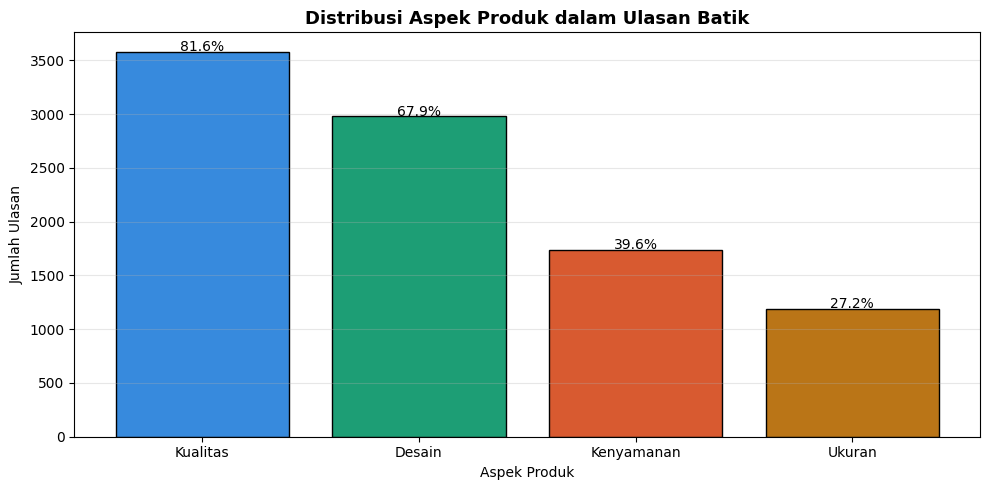


Distribusi Aspek Dominan per Ulasan (aspek_keyword):
aspek_keyword
Kualitas      2790
Desain        1278
Ukuran         182
Kenyamanan     140
Name: count, dtype: int64


In [87]:
aspek_batik = {
    'Desain'     : ['desain', 'motif', 'corak', 'warna', 'cantik', 'indah',
                    'menarik', 'elegan', 'modern', 'keren', 'gambar', 'pola',
                    'model', 'tampil', 'estetik', 'visual'],
    'Kualitas'   : ['bahan', 'kain', 'halus', 'lembut', 'tebal', 'tipis',
                    'katun', 'polyester', 'jahit', 'rapi', 'kualitas',
                    'furing', 'lapis', 'kancing', 'awet', 'bagus',
                    'tekstur', 'material', 'benang', 'kuat'],
    'Kenyamanan' : ['nyaman', 'kenyaman', 'comfort', 'enak', 'adem', 'sejuk',
                    'gerah', 'panas', 'dingin', 'segar', 'keringat',
                    'bernapas', 'ringan', 'berat'],
    'Ukuran'     : ['ukuran', 'size', 'pas', 'cocok', 'besar', 'kecil',
                    'panjang', 'pendek', 'slim', 'ramping', 'fitting',
                    'xl', 'xxl', 'longgar', 'sempit', 'fit'],
}

aspek_counts = {}
for aspek, keywords in aspek_batik.items():
    count = sum(1 for tokens in df_clean['tokens_stem']
                if any(k in tokens for k in keywords))
    aspek_counts[aspek] = count

aspek_df = pd.DataFrame(list(aspek_counts.items()), columns=['Aspek', 'Jumlah Ulasan'])
aspek_df['Persentase (%)'] = (aspek_df['Jumlah Ulasan'] / len(df_clean) * 100).round(1)
aspek_df = aspek_df.sort_values('Jumlah Ulasan', ascending=False).reset_index(drop=True)

print('=== Distribusi Aspek dalam Ulasan ===')
print(aspek_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors_aspek_eda = ['#378ADD', '#1D9E75', '#D85A30', '#BA7517']
bars = ax.bar(aspek_df['Aspek'], aspek_df['Jumlah Ulasan'],
              color=colors_aspek_eda[:len(aspek_df)], edgecolor='black')
ax.set_title('Distribusi Aspek Produk dalam Ulasan Batik', fontsize=13, fontweight='bold')
ax.set_xlabel('Aspek Produk')
ax.set_ylabel('Jumlah Ulasan')
ax.grid(axis='y', alpha=0.3)
for bar, pct in zip(bars, aspek_df['Persentase (%)']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{pct}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('distribusi_aspek.png', dpi=150, bbox_inches='tight')
plt.show()

def assign_aspek_dominan(tokens):
    skor = {}
    for aspek, keywords in aspek_batik.items():
        skor[aspek] = sum(1 for t in tokens if t in keywords)
    best_aspek = max(skor, key=skor.get)
    return best_aspek if skor[best_aspek] > 0 else 'Kualitas'

df_clean['aspek_keyword'] = df_clean['tokens_stem'].apply(assign_aspek_dominan)
print('\nDistribusi Aspek Dominan per Ulasan (aspek_keyword):')
print(df_clean['aspek_keyword'].value_counts())

# 4.7 Simpan Dataset Hasil Preprocessing

In [88]:
kolom_simpan = ['User Id', 'User Name', 'Comment', 'text_preprocessed',
                'Rating', 'Detail Rating', 'Product Id', 'Product Name', 'Shop Id',
                'aspek_keyword']
kolom_ada = [c for c in kolom_simpan if c in df_clean.columns]
df_final = df_clean[kolom_ada].copy()
df_final.columns = [c if c != 'text_preprocessed' else 'Text_Preprocessed' for c in df_final.columns]

df_final.to_csv('batik_preprocessed.csv', index=False, encoding='utf-8')
print(f'✅ Dataset tersimpan: batik_preprocessed.csv ({len(df_final)} baris)')
df_final.head()

✅ Dataset tersimpan: batik_preprocessed.csv (4390 baris)


,User Id,User Name,Comment,Text_Preprocessed,Rating,Detail Rating,Product Id,Product Name,Shop Id,aspek_keyword
0,239772482,l*****e,Desain:bagus\nBahan:cukup berkualitas\nKenyama...,desain bagus bahan cukup kualitas nyaman furin...,4,product_quality: 4\nseller_service: 5\ndeliver...,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,Kualitas
1,818084703,m*****5,Desain:keren dan moderen\nBahan:bagus\nTekstur...,desain bagus moderen bahan bagus tekstur lembu...,4,product_quality: 4\nseller_service: 4\ndeliver...,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,Kualitas
2,227253735,ari.irawan,Desain:batik dg desain yg bagus\nBahan:halus d...,desain batik desain bagus bahan halus nyaman t...,4,product_quality: 4,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,Kualitas
3,1316081004,garasibarbersop,Desain:bagus\nBahan:lmbut\nKenyamanan:passs di...,desain bagus bahan lmbut nyaman passs dipkainy...,4,product_quality: 4,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,Kualitas
4,311327546,b*****1,Desain:motif mewah dan hidup\nBahan:kualitas s...,desain motif mewah hidup bahan kualitas sesuai...,4,product_quality: 4\nseller_service: 5\ndeliver...,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,Kualitas


---
# 4.9 Pemodelan Topik Menggunakan LDA

Sesuai metodologi BAB III Skripsi (diubah dari BERTopic ke LDA):
- **Representasi**  : Bag-of-Words via `CountVectorizer`
- **Model**        : `LatentDirichletAllocation` (sklearn)
- **Jumlah Topik** : K = 4 (Desain, Kualitas, Kenyamanan, Ukuran)
- **Evaluasi**     : Perplexity & Log-Likelihood

## 4.9.1 Import Library LDA

In [89]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

print('✅ Semua library LDA berhasil di-import!')

✅ Semua library LDA berhasil di-import!


## 4.9.2 Persiapan Data untuk LDA

In [90]:
assert 'df_clean' in dir(), '❌ df_clean belum ada!'
assert 'text_preprocessed' in df_clean.columns, '❌ Kolom text_preprocessed belum ada!'

# Filter dokumen terlalu pendek
df_clean['token_count'] = df_clean['text_preprocessed'].str.split().str.len()
mask_valid = df_clean['token_count'] >= 3
docs_valid = df_clean.loc[mask_valid, 'text_preprocessed'].tolist()
idx_valid  = df_clean.loc[mask_valid].index.tolist()

print(f'Total dokumen           : {len(df_clean)}')
print(f'Dokumen valid (≥3 kata) : {len(docs_valid)}')
print(f'Dokumen dibuang         : {len(df_clean) - len(docs_valid)}')
print(f'\nContoh dokumen:\n  [{docs_valid[0]}]\n  [{docs_valid[1]}]')

Total dokumen           : 4390
Dokumen valid (≥3 kata) : 4165
Dokumen dibuang         : 225

Contoh dokumen:
  [desain bagus bahan cukup kualitas nyaman furing tinggi pas]
  [desain bagus moderen bahan bagus tekstur lembut halus kirim cepat peking rapi]


## 4.9.3 Vektorisasi Teks (CountVectorizer / Bag-of-Words)

LDA menggunakan representasi **Bag-of-Words** (BoW), bukan embedding neural seperti BERTopic.
CountVectorizer mengubah setiap dokumen menjadi vektor frekuensi kata.

In [91]:
# CountVectorizer: unigram + bigram, min_df=2, max_df=0.95, max 5000 fitur
vectorizer = CountVectorizer(
    min_df=2,             # kata harus muncul di minimal 2 dokumen
    max_df=0.95,          # abaikan kata yang terlalu umum (>95% dokumen)
    ngram_range=(1, 2),   # unigram + bigram
    max_features=5000     # batas fitur
)

dtm = vectorizer.fit_transform(docs_valid)  # Document-Term Matrix
vocab = vectorizer.get_feature_names_out()

print(f'✅ Vektorisasi selesai!')
print(f'   Shape DTM   : {dtm.shape}  (dokumen × fitur)')
print(f'   Ukuran vocab: {len(vocab)}')
print(f'   Contoh vocab: {list(vocab[:10])}')

✅ Vektorisasi selesai!
   Shape DTM   : (4165, 5000)  (dokumen × fitur)
   Ukuran vocab: 5000
   Contoh vocab: ['1nya', '30an', '30rb', '37rb', '3xl', '3xl kecil', '40rb', '40rban', '45kg', '4xl']


## 4.9.4 Training LDA

**Rumus dasar LDA:**
- Setiap dokumen d merupakan campuran K topik → distribusi θ_d ~ Dirichlet(α)
- Setiap topik k merupakan distribusi atas kata → φ_k ~ Dirichlet(β)
- LDA mempelajari θ dan φ secara bersama menggunakan variational EM

**Parameter utama:**
- `n_components` = K = 4 (sesuai 4 aspek: Desain, Kualitas, Kenyamanan, Ukuran)
- `max_iter` = 50 iterasi EM
- `learning_method` = 'batch' (lebih stabil untuk dataset kecil–sedang)
- `random_state` = 42 (reproducibility)

In [92]:
N_TOPICS = 4  # K = 4 aspek

lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=50,
    learning_method='batch',   # full batch EM — lebih stabil dari 'online'
    learning_decay=0.7,
    random_state=42,
    n_jobs=-1                  # pakai semua core CPU
)

print('⏳ Training LDA... (proses ini memerlukan beberapa menit)')
lda_model.fit(dtm)
print('✅ LDA selesai dilatih!')
print(f'   Log-Likelihood : {lda_model.score(dtm):.2f}')
print(f'   Perplexity     : {lda_model.perplexity(dtm):.2f}')
print()
print('Catatan interpretasi:')
print('  Log-Likelihood lebih tinggi (kurang negatif) → model lebih baik')
print('  Perplexity lebih rendah → model lebih baik (lebih tidak "bingung")')

⏳ Training LDA... (proses ini memerlukan beberapa menit)
✅ LDA selesai dilatih!
   Log-Likelihood : -621388.78
   Perplexity     : 855.29

Catatan interpretasi:
  Log-Likelihood lebih tinggi (kurang negatif) → model lebih baik
  Perplexity lebih rendah → model lebih baik (lebih tidak "bingung")


## 4.9.5 Eksplorasi Kata Kunci per Topik LDA

In [93]:
TOP_N_WORDS = 15  # kata kunci yang ditampilkan per topik

def get_top_words_lda(model, feature_names, top_n=15):
    """Mengembalikan dict {topic_id: [(word, score), ...]}"""
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-top_n - 1:-1]
        topics[topic_idx] = [(feature_names[i], topic[i]) for i in top_indices]
    return topics

lda_topics = get_top_words_lda(lda_model, vocab, top_n=TOP_N_WORDS)

print('=== Kata Kunci per Topik LDA ===')
for tid, words_scores in lda_topics.items():
    words = [w for w, s in words_scores[:10]]
    print(f'  Topik {tid} : {" | ".join(words)}')

=== Kata Kunci per Topik LDA ===
  Topik 0 : warna | bagus | tampil | pesan | sesuai | sama | kirim | ukur | pas | beli
  Topik 1 : nyaman | bagus | bahan | desain | warna | sejuk | tarik | sangat | lembut | pakai
  Topik 2 : bahan | tipis | sesuai | warna | desain | harga | ukur | bagus | bahan tipis | lumayan
  Topik 3 : sesuai | rapi | jahit | pesan | terima | bagus | kualitas | kasih | terima kasih | oke


## 4.9.6 Mapping Topik LDA → Aspek Produk Batik

In [94]:
aspek_keywords_lda = {
    'Desain'     : ['desain', 'motif', 'corak', 'warna', 'cantik', 'indah',
                    'menarik', 'elegan', 'model', 'gambar', 'pola', 'keren'],
    'Kenyamanan' : ['nyaman', 'kenyaman', 'comfort', 'enak', 'adem', 'sejuk',
                    'gerah', 'panas', 'dingin', 'segar'],
    'Kualitas'   : ['bahan', 'kain', 'halus', 'lembut', 'tebal', 'tipis',
                    'jahit', 'rapi', 'kualitas', 'awet', 'furing', 'katun'],
    'Ukuran'     : ['ukuran', 'size', 'pas', 'cocok', 'besar', 'kecil',
                    'panjang', 'pendek', 'slim', 'fitting', 'xl', 'xxl'],
}

ASPEK_LIST = list(aspek_keywords_lda.keys())  # ['Desain','Kenyamanan','Kualitas','Ukuran']

def score_matrix(top_n=15):
    """Buat matriks skor topik x aspek (overlap kata kunci)."""
    mat = {}
    for tid in range(N_TOPICS):
        topic_words = set(w.lower() for w, s in lda_topics[tid][:top_n])
        mat[tid] = {asp: len(topic_words & set(kws))
                    for asp, kws in aspek_keywords_lda.items()}
    return mat

def hungarian_assignment(mat):
    """
    Greedy unique assignment: setiap aspek mendapat TEPAT SATU topik terbaik.
    Jika N_TOPICS > N_ASPEK, topik sisa dipetakan ke aspek terdekat (boleh duplikat).
    Jika N_TOPICS < N_ASPEK, aspek yang tidak dapat topik → tidak muncul (wajar).
    """
    assigned_aspek = set()
    mapping = {}

    # Urutkan (topik, aspek) berdasarkan skor tertinggi
    pairs = []
    for tid in range(N_TOPICS):
        for asp in ASPEK_LIST:
            pairs.append((mat[tid][asp], tid, asp))
    pairs.sort(key=lambda x: -x[0])

    # Fase 1: assign unik (tiap aspek max 1 topik primer)
    assigned_topic_primary = set()
    for score, tid, asp in pairs:
        if tid not in assigned_topic_primary and asp not in assigned_aspek:
            mapping[tid] = asp
            assigned_aspek.add(asp)
            assigned_topic_primary.add(tid)

    # Fase 2: topik yang belum dapat aspek → ambil aspek dengan skor tertinggi (boleh duplikat)
    for tid in range(N_TOPICS):
        if tid not in mapping:
            best_asp = max(ASPEK_LIST, key=lambda a: mat[tid][a])
            mapping[tid] = best_asp

    return mapping

mat = score_matrix(top_n=15)
topic_aspek_map = hungarian_assignment(mat)

print('=== Auto-Mapping Topik LDA → Aspek (Unique Assignment) ===')
for tid in range(N_TOPICS):
    aspek = topic_aspek_map[tid]
    scores_str = ', '.join(f'{a}={mat[tid][a]}' for a in ASPEK_LIST)
    words = [w for w, s in lda_topics[tid][:6]]
    print(f'  Topik {tid} → {aspek:<12} | skor: [{scores_str}] | kata: {words}')

aspek_terpetakan = set(topic_aspek_map.values())
aspek_hilang = set(ASPEK_LIST) - aspek_terpetakan
print()
if aspek_hilang:
    print(f'⚠️  Aspek tanpa topik: {aspek_hilang} — override manual di bawah jika perlu.')
else:
    print('✅ Semua aspek mendapat topik. Override manual di bawah jika mapping kurang tepat.')
print('   Contoh override: topic_aspek_map[2] = \'Kenyamanan\'')


=== Auto-Mapping Topik LDA → Aspek (Unique Assignment) ===
  Topik 0 → Desain       | skor: [Desain=2, Kenyamanan=0, Kualitas=0, Ukuran=1] | kata: ['warna', 'bagus', 'tampil', 'pesan', 'sesuai', 'sama']
  Topik 1 → Kualitas     | skor: [Desain=2, Kenyamanan=2, Kualitas=4, Ukuran=0] | kata: ['nyaman', 'bagus', 'bahan', 'desain', 'warna', 'sejuk']
  Topik 2 → Kenyamanan   | skor: [Desain=2, Kenyamanan=1, Kualitas=3, Ukuran=1] | kata: ['bahan', 'tipis', 'sesuai', 'warna', 'desain', 'harga']
  Topik 3 → Ukuran       | skor: [Desain=0, Kenyamanan=0, Kualitas=3, Ukuran=0] | kata: ['sesuai', 'rapi', 'jahit', 'pesan', 'terima', 'bagus']

✅ Semua aspek mendapat topik. Override manual di bawah jika mapping kurang tepat.
   Contoh override: topic_aspek_map[2] = 'Kenyamanan'


## 4.9.7 Override Manual Mapping (Opsional)

In [95]:
# ============================================================
# Sesuaikan mapping di sini jika auto-mapping kurang akurat.
# Lihat kata kunci di Cell 4.9.5 dan tentukan aspek yang paling cocok.
# ============================================================

# Contoh override (hapus '#' untuk mengaktifkan):
# topic_aspek_map[0] = 'Desain'
# topic_aspek_map[1] = 'Kualitas'
# topic_aspek_map[2] = 'Kenyamanan'
# topic_aspek_map[3] = 'Ukuran'

print('=== Mapping Final Topik → Aspek ===')
for tid, aspek in topic_aspek_map.items():
    print(f'  Topik {tid} → {aspek}')

=== Mapping Final Topik → Aspek ===
  Topik 1 → Kualitas
  Topik 0 → Desain
  Topik 2 → Kenyamanan
  Topik 3 → Ukuran


## 4.9.8 Assign Aspek ke Setiap Dokumen

In [96]:
# Hitung distribusi topik per dokumen (θ)
# Shape: (n_docs_valid, N_TOPICS)
doc_topic_dist = lda_model.transform(dtm)

# Topik dominan = argmax dari distribusi topik
dominant_topics = doc_topic_dist.argmax(axis=1)
max_probs       = doc_topic_dist.max(axis=1)

# Masukkan ke df_clean
df_clean['topic_lda']  = -1
df_clean['aspek_lda']  = 'Unknown'
df_clean['topic_prob'] = 0.0

df_clean.loc[idx_valid, 'topic_lda']  = dominant_topics
df_clean.loc[idx_valid, 'topic_prob'] = max_probs
df_clean['aspek_lda'] = df_clean['topic_lda'].map(
    lambda t: topic_aspek_map.get(t, 'Unknown') if t != -1 else 'Unknown'
)

aspek_dist = df_clean[df_clean['aspek_lda'] != 'Unknown']['aspek_lda'].value_counts()
print('=== Distribusi Aspek (LDA) ===')
print(aspek_dist)
total_valid = (df_clean['aspek_lda'] != 'Unknown').sum()
print(f'\nTotal dokumen ter-assign : {total_valid}')
print(f'Total dokumen tidak valid: {(df_clean["aspek_lda"] == "Unknown").sum()}')

=== Distribusi Aspek (LDA) ===
aspek_lda
Kualitas      1245
Kenyamanan    1185
Desain         966
Ukuran         769
Name: count, dtype: int64

Total dokumen ter-assign : 4165
Total dokumen tidak valid: 225


## 4.9.9 Visualisasi Distribusi Aspek LDA

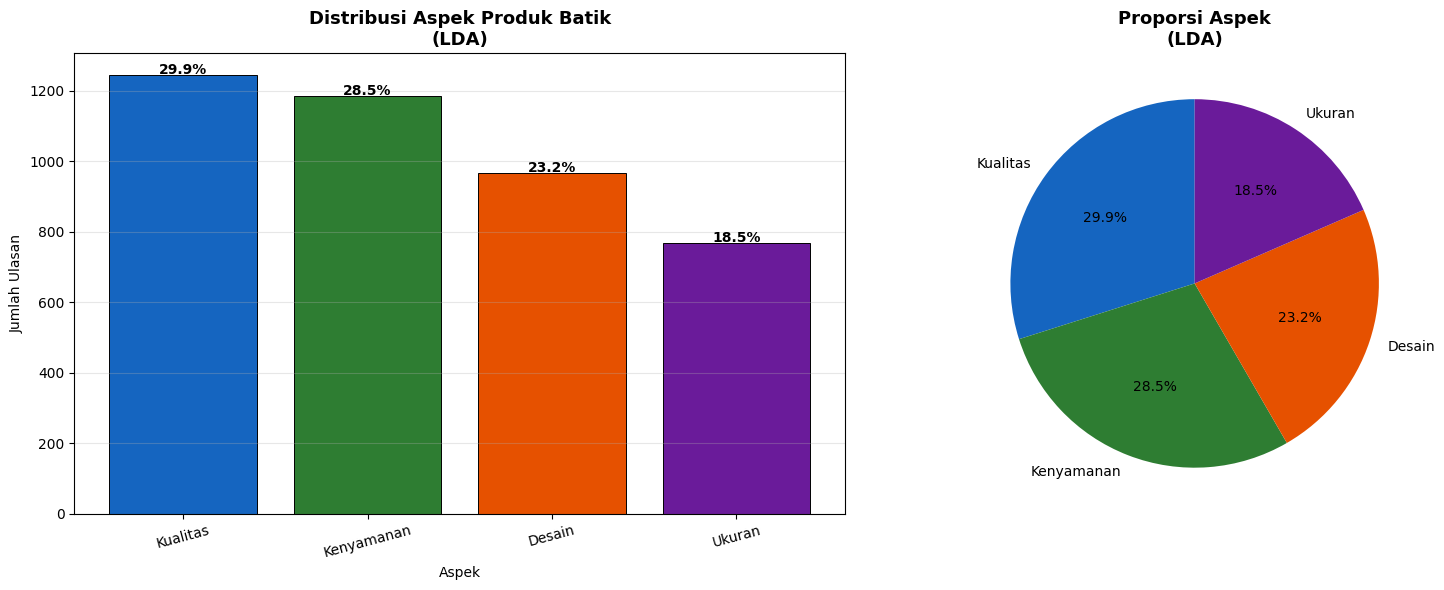

✅ Visualisasi distribusi aspek LDA tersimpan.


In [97]:
df_viz = df_clean[df_clean['aspek_lda'] != 'Unknown'].copy()
aspek_counts_lda = df_viz['aspek_lda'].value_counts()
aspek_pct_lda    = (aspek_counts_lda / aspek_counts_lda.sum() * 100).round(1)

colors_aspek = ['#1565c0', '#2e7d32', '#e65100', '#6a1b9a']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].bar(aspek_counts_lda.index, aspek_counts_lda.values,
                   color=colors_aspek[:len(aspek_counts_lda)], edgecolor='black', linewidth=0.7)
axes[0].set_title('Distribusi Aspek Produk Batik\n(LDA)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Aspek')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)
for bar, pct in zip(bars, aspek_pct_lda.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 3,
                 f'{pct}%', ha='center', fontsize=10, fontweight='bold')

axes[1].pie(aspek_counts_lda.values,
            labels=aspek_counts_lda.index,
            autopct='%1.1f%%',
            colors=colors_aspek[:len(aspek_counts_lda)],
            startangle=90,
            textprops={'fontsize': 10})
axes[1].set_title('Proporsi Aspek\n(LDA)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_aspek_lda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi distribusi aspek LDA tersimpan.')

## 4.9.10 Visualisasi Kata Kunci per Aspek (Bar Chart)

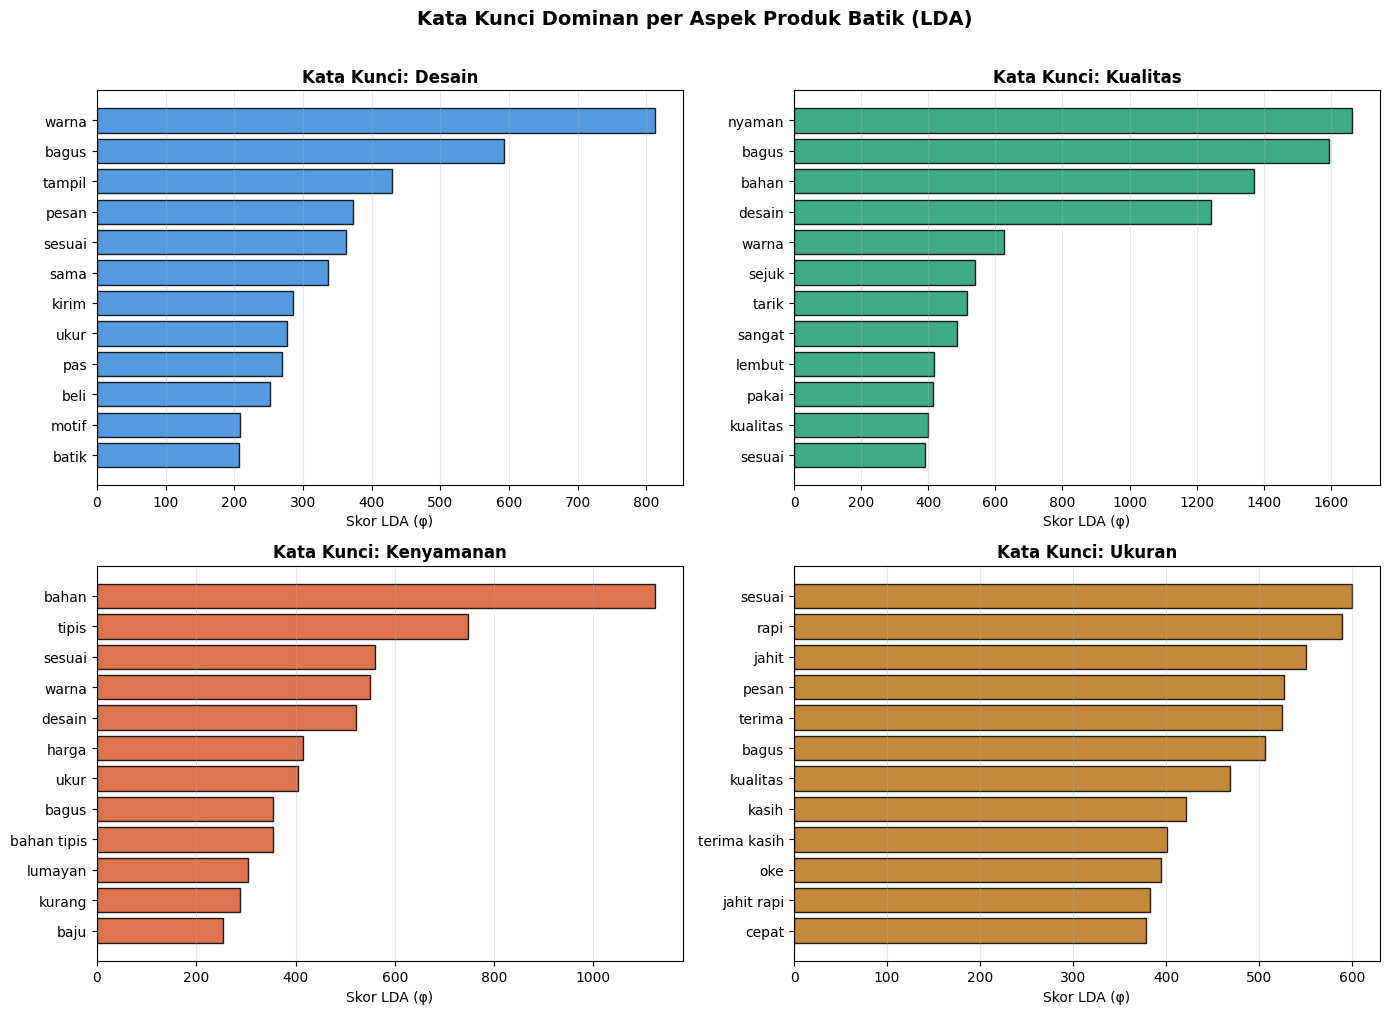

✅ Visualisasi kata kunci LDA tersimpan.


In [98]:
ASPEK_URUT = ['Desain', 'Kualitas', 'Kenyamanan', 'Ukuran']
aspek_unik = [a for a in ASPEK_URUT if a in aspek_counts_lda.index]
n_aspek = len(aspek_unik)
cols = min(2, n_aspek)
rows_plot = (n_aspek + cols - 1) // cols

fig, axes = plt.subplots(rows_plot, cols, figsize=(7 * cols, 5 * rows_plot))
if n_aspek == 1:
    axes = [axes]
else:
    axes = axes.flatten()

colors_bar = ['#378ADD', '#1D9E75', '#D85A30', '#BA7517']

for i, aspek in enumerate(aspek_unik):
    # Kumpulkan topik yang dipetakan ke aspek ini
    topik_ids = [t for t, a in topic_aspek_map.items() if a == aspek]
    if not topik_ids:
        axes[i].text(0.5, 0.5, 'Tidak ada topik', ha='center', va='center')
        axes[i].axis('off')
        continue

    # Gabungkan kata kunci dari semua topik aspek ini
    word_scores = {}
    for tid in topik_ids:
        for word, score in lda_topics[tid][:15]:
            word_scores[word] = word_scores.get(word, 0) + score

    top_ws = sorted(word_scores.items(), key=lambda x: x[1], reverse=True)[:12]
    words  = [w for w, s in top_ws][::-1]
    scores = [s for w, s in top_ws][::-1]

    axes[i].barh(words, scores, color=colors_bar[i], edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Kata Kunci: {aspek}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Skor LDA (φ)')
    axes[i].grid(axis='x', alpha=0.3)

for j in range(len(aspek_unik), len(axes)):
    axes[j].axis('off')

plt.suptitle('Kata Kunci Dominan per Aspek Produk Batik (LDA)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('kata_kunci_aspek_lda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi kata kunci LDA tersimpan.')

## 4.9.11 Tabel Sampel Hasil Aspek LDA

In [99]:
print('=== Sampel Hasil Penugasan Aspek LDA ===')
sample_cols = ['Comment', 'text_preprocessed', 'aspek_lda', 'topic_prob', 'Rating']
sample_cols_ada = [c for c in sample_cols if c in df_clean.columns]
tabel_sampel = df_clean[df_clean['aspek_lda'] != 'Unknown'][sample_cols_ada].head(12)
tabel_sampel.columns = ['Ulasan Asli', 'Teks Preprocessed', 'Aspek', 'Prob Topik', 'Rating'][:len(sample_cols_ada)]
print(tabel_sampel.to_string(index=False))

=== Sampel Hasil Penugasan Aspek LDA ===
                                                                                                                                                                                                                                     Ulasan Asli                                                                                                                                                  Teks Preprocessed      Aspek  Prob Topik  Rating
                                                                                                                                             Desain:bagus\nBahan:cukup berkualitas\nKenyamanan:ada furing nya\n\nBuat BB 82 dan tinggi 168.. Pas                                                                                                         desain bagus bahan cukup kualitas nyaman furing tinggi pas   Kualitas    0.508092       4
                                                                                         

## 4.9.12 Evaluasi Model LDA

**Perplexity** mengukur seberapa baik model memprediksi data:
- Perplexity = exp(- log-likelihood / N_tokens)
- Nilai lebih **rendah** = model lebih baik

**Log-Likelihood** langsung dari variational EM (ELBO):
- Nilai lebih **tinggi (kurang negatif)** = model lebih baik

**Uji K Optimal (Elbow Method)** membandingkan perplexity untuk K = 2–8 topik.

=== Evaluasi Model LDA ===
  Log-Likelihood : -621388.78
  Perplexity     : 855.29

⏳ Menghitung perplexity untuk K = 2..8 (untuk Elbow Method)...
   K=2: Perplexity = 886.13
   K=3: Perplexity = 854.50
   K=4: Perplexity = 859.76
   K=5: Perplexity = 870.31
   K=6: Perplexity = 876.23
   K=7: Perplexity = 897.76
   K=8: Perplexity = 906.80


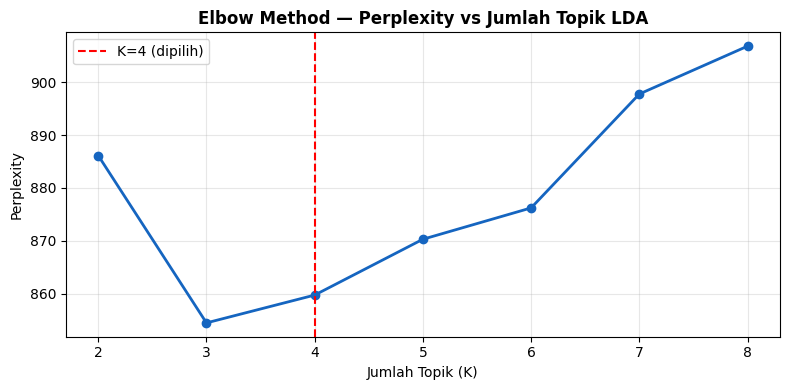

✅ Elbow chart tersimpan: lda_elbow.png


In [100]:
log_lik  = lda_model.score(dtm)
perp     = lda_model.perplexity(dtm)

print('=== Evaluasi Model LDA ===')
print(f'  Log-Likelihood : {log_lik:.2f}')
print(f'  Perplexity     : {perp:.2f}')

# --- Elbow: Perplexity vs K ---
print('\n⏳ Menghitung perplexity untuk K = 2..8 (untuk Elbow Method)...')
k_range = range(2, 9)
perplexities = []
for k in k_range:
    lda_k = LatentDirichletAllocation(
        n_components=k, max_iter=30,
        learning_method='batch', random_state=42
    )
    lda_k.fit(dtm)
    perplexities.append(lda_k.perplexity(dtm))
    print(f'   K={k}: Perplexity = {lda_k.perplexity(dtm):.2f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), perplexities, marker='o', color='#1565c0', linewidth=2)
ax.axvline(x=N_TOPICS, color='red', linestyle='--', label=f'K={N_TOPICS} (dipilih)')
ax.set_title('Elbow Method — Perplexity vs Jumlah Topik LDA', fontsize=12, fontweight='bold')
ax.set_xlabel('Jumlah Topik (K)')
ax.set_ylabel('Perplexity')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lda_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Elbow chart tersimpan: lda_elbow.png')

## 4.9.13 Visualisasi pyLDAvis (Interaktif)

In [101]:
# pyLDAvis memvisualisasikan jarak antar-topik dan kata kunci dominan
try:
    import pyLDAvis
    import pyLDAvis.lda_model as pyldavis_sklearn
    pyLDAvis.enable_notebook()

    lda_display = pyldavis_sklearn.prepare(
        lda_model, dtm, vectorizer, sort_topics=False
    )
    pyLDAvis.save_html(lda_display, 'lda_visualization.html')
    print('✅ pyLDAvis tersimpan: lda_visualization.html')
    lda_display  # tampilkan inline di notebook
except ImportError:
    print('⚠️  pyLDAvis tidak terinstall. Jalankan: pip install pyLDAvis')
except Exception as e:
    print(f'⚠️  pyLDAvis gagal: {e}')

✅ pyLDAvis tersimpan: lda_visualization.html


## 4.9.14 Simpan Hasil LDA

In [102]:
kolom_simpan_lda = ['User Id', 'User Name', 'Comment', 'text_preprocessed',
                    'Rating', 'Product Id', 'Product Name', 'Shop Id',
                    'aspek_lda', 'topic_lda', 'topic_prob']
kolom_ada_lda = [c for c in kolom_simpan_lda if c in df_clean.columns]
df_lda = df_clean[kolom_ada_lda].copy()

df_lda.to_csv('batik_lda.csv', index=False, encoding='utf-8')
print(f'✅ Dataset tersimpan: batik_lda.csv ({len(df_lda)} baris)')
print(f'   Kolom: {list(df_lda.columns)}')

✅ Dataset tersimpan: batik_lda.csv (4390 baris)
   Kolom: ['User Id', 'User Name', 'Comment', 'text_preprocessed', 'Rating', 'Product Id', 'Product Name', 'Shop Id', 'aspek_lda', 'topic_lda', 'topic_prob']


## 4.9.15 Ringkasan Hasil LDA

In [103]:
print('=' * 60)
print('RINGKASAN HASIL PEMODELAN LDA')
print('=' * 60)
print(f'  Model          : Latent Dirichlet Allocation (sklearn)')
print(f'  Representasi   : CountVectorizer (BoW), ngram (1,2), max_features=5000')
print(f'  Jumlah Topik K : {N_TOPICS}')
print(f'  Iterasi        : 50 (batch EM)')
print(f'  Log-Likelihood : {log_lik:.2f}')
print(f'  Perplexity     : {perp:.2f}')
print(f'\n  Mapping Topik → Aspek:')
for tid, aspek in topic_aspek_map.items():
    print(f'    Topik {tid} → {aspek}')
print(f'\n  Distribusi Aspek Final (K=4):')
for aspek in ['Desain', 'Kualitas', 'Kenyamanan', 'Ukuran']:
    count = (df_clean['aspek_lda'] == aspek).sum()
    pct   = count / len(df_clean) * 100
    print(f'    {aspek:12s}: {count:4d} ulasan ({pct:.1f}%)')
print(f'\n✅ LDA selesai. Lanjut ke tahap EFM (Section 4.10)')
print('=' * 60)

RINGKASAN HASIL PEMODELAN LDA
  Model          : Latent Dirichlet Allocation (sklearn)
  Representasi   : CountVectorizer (BoW), ngram (1,2), max_features=5000
  Jumlah Topik K : 4
  Iterasi        : 50 (batch EM)
  Log-Likelihood : -621388.78
  Perplexity     : 855.29

  Mapping Topik → Aspek:
    Topik 1 → Kualitas
    Topik 0 → Desain
    Topik 2 → Kenyamanan
    Topik 3 → Ukuran

  Distribusi Aspek Final (K=4):
    Desain      :  966 ulasan (22.0%)
    Kualitas    : 1245 ulasan (28.4%)
    Kenyamanan  : 1185 ulasan (27.0%)
    Ukuran      :  769 ulasan (17.5%)

✅ LDA selesai. Lanjut ke tahap EFM (Section 4.10)


---
# 4.10 Explicit Factor Model (EFM)

Tahap ini **sama persis** dengan versi BERTopic, hanya kolom aspek berubah dari `aspek_bertopic` → `aspek_lda`.

Sesuai metodologi skripsi BAB III (Sections 3.7–3.11):
- **3.7** Splitting Data (80:20)
- **3.8** Pembobotan Aspek Pengguna (w_au)
- **3.9** Kualitas Produk per Aspek (q_pa)
- **3.10** Prediksi Rating EFM
- **3.11** Evaluasi RMSE, Precision-K, dan Explainability

## 4.10.1 Load Dataset Hasil LDA

In [104]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Load hasil LDA
df_lda_load = pd.read_csv('batik_lda.csv')

# Kolom aspek dari LDA adalah 'aspek_lda'
KOLOM_WAJIB = ['User Id', 'Product Id', 'Rating', 'aspek_lda']
for k in KOLOM_WAJIB:
    assert k in df_lda_load.columns, f"❌ Kolom '{k}' tidak ditemukan!"

print('✅ Dataset LDA berhasil dimuat!')
print(f'   Total baris    : {len(df_lda_load):,}')
print(f'   Pengguna unik  : {df_lda_load["User Id"].nunique():,}')
print(f'   Produk unik    : {df_lda_load["Product Id"].nunique():,}')
print(f'   Aspek unik     : {df_lda_load["aspek_lda"].nunique():,}')
print(f'   Aspek tersedia : {sorted(df_lda_load["aspek_lda"].dropna().unique())}')
df_lda_load.head()

✅ Dataset LDA berhasil dimuat!
   Total baris    : 4,390
   Pengguna unik  : 4,301
   Produk unik    : 113
   Aspek unik     : 5
   Aspek tersedia : ['Desain', 'Kenyamanan', 'Kualitas', 'Ukuran', 'Unknown']


,User Id,User Name,Comment,text_preprocessed,Rating,Product Id,Product Name,Shop Id,aspek_lda,topic_lda,topic_prob
0,239772482,l*****e,Desain:bagus\nBahan:cukup berkualitas\nKenyama...,desain bagus bahan cukup kualitas nyaman furin...,4,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,Kualitas,1,0.508092
1,818084703,m*****5,Desain:keren dan moderen\nBahan:bagus\nTekstur...,desain bagus moderen bahan bagus tekstur lembu...,4,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,Kualitas,1,0.655332
2,227253735,ari.irawan,Desain:batik dg desain yg bagus\nBahan:halus d...,desain batik desain bagus bahan halus nyaman t...,4,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,Kualitas,1,0.730242
3,1316081004,garasibarbersop,Desain:bagus\nBahan:lmbut\nKenyamanan:passs di...,desain bagus bahan lmbut nyaman passs dipkainy...,4,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,Kualitas,1,0.955258
4,311327546,b*****1,Desain:motif mewah dan hidup\nBahan:kualitas s...,desain motif mewah hidup bahan kualitas sesuai...,4,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,Kenyamanan,2,0.507701


## 4.10.2 Definisi Aspek Final & Normalisasi

In [105]:
ASPEK_FINAL = ['Desain', 'Kualitas', 'Kenyamanan', 'Ukuran']

# Normalisasi aspek_lda ke nama aspek final
aspek_map_lda = {}
for a in df_lda_load['aspek_lda'].dropna().unique():
    a_lower = a.lower()
    if any(x in a_lower for x in ['desain', 'motif', 'warna', 'corak']):
        aspek_map_lda[a] = 'Desain'
    elif any(x in a_lower for x in ['nyaman', 'kenyaman', 'comfort', 'adem', 'sejuk']):
        aspek_map_lda[a] = 'Kenyamanan'
    elif any(x in a_lower for x in ['kual', 'bahan', 'jahit', 'kain', 'katun', 'furing']):
        aspek_map_lda[a] = 'Kualitas'
    elif any(x in a_lower for x in ['ukuran', 'size', 'fit', 'pas']):
        aspek_map_lda[a] = 'Ukuran'
    else:
        aspek_map_lda[a] = 'Kualitas'  # fallback

df_lda_load['aspek_norm'] = df_lda_load['aspek_lda'].map(aspek_map_lda)

# Fallback dari aspek_keyword jika tersedia
aspek_tercakup = set(df_lda_load['aspek_norm'].dropna().unique())
aspek_hilang   = set(ASPEK_FINAL) - aspek_tercakup

if aspek_hilang and 'aspek_keyword' in df_lda_load.columns:
    print(f'⚠️  Fallback aspek_keyword untuk: {sorted(aspek_hilang)}')
    mask_unknown = df_lda_load['aspek_norm'].isna() | (df_lda_load['aspek_lda'] == 'Unknown')
    for aspek in aspek_hilang:
        mask_aspek = mask_unknown & (df_lda_load['aspek_keyword'] == aspek)
        df_lda_load.loc[mask_aspek, 'aspek_norm'] = aspek

print(f'\nAspek tercakup LDA : {sorted(aspek_tercakup)}')
print(f'Aspek tidak tercakup: {sorted(aspek_hilang) if aspek_hilang else "Tidak ada ✅"}')
print(f'\nDistribusi aspek (setelah normalisasi):')
print(df_lda_load['aspek_norm'].value_counts())

for a in ASPEK_FINAL:
    n = (df_lda_load['aspek_norm'] == a).sum()
    status = '✅' if n > 0 else '❌ TIDAK ADA DATA'
    print(f'  {a:<12}: {n:>4} ulasan {status}')


Aspek tercakup LDA : ['Desain', 'Kenyamanan', 'Kualitas', 'Ukuran']
Aspek tidak tercakup: Tidak ada ✅

Distribusi aspek (setelah normalisasi):
aspek_norm
Kualitas      1470
Kenyamanan    1185
Desain         966
Ukuran         769
Name: count, dtype: int64
  Desain      :  966 ulasan ✅
  Kualitas    : 1470 ulasan ✅
  Kenyamanan  : 1185 ulasan ✅
  Ukuran      :  769 ulasan ✅


## 4.10.3 Splitting Data (80:20)

In [106]:
df_model = df_lda_load[df_lda_load['Rating'].notna()].copy()
df_model['Rating'] = df_model['Rating'].astype(float)

train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42,
    stratify=df_model['Rating'].astype(int)
)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print('✅ Splitting Data selesai!')
print(f'   Data latih (80%) : {len(train_df):,} baris')
print(f'   Data uji  (20%)  : {len(test_df):,} baris')
print('\nDistribusi rating — Data Latih:')
print(train_df['Rating'].value_counts().sort_index().to_string())
print('\nDistribusi rating — Data Uji:')
print(test_df['Rating'].value_counts().sort_index().to_string())

✅ Splitting Data selesai!
   Data latih (80%) : 3,512 baris
   Data uji  (20%)  : 878 baris

Distribusi rating — Data Latih:
Rating
1.0     356
2.0     304
3.0     585
4.0     780
5.0    1487

Distribusi rating — Data Uji:
Rating
1.0     89
2.0     76
3.0    146
4.0    195
5.0    372


## 4.10.4 Pembobotan Aspek Pengguna (w_au)

Sesuai skripsi BAB III.3.8, **Rumus (3.2)**:

$$w_{u,a} = \frac{f_{u,a}}{\sum_{a'} f_{u,a'}}$$

In [107]:
def hitung_bobot_pengguna(df_train, aspek_final):
    df_aspek = df_train[df_train['aspek_norm'].notna()].copy()
    freq = df_aspek.groupby(['User Id', 'aspek_norm']).size().reset_index(name='freq')

    bobot_user = {}
    for user_id, grp in freq.groupby('User Id'):
        total_freq = grp['freq'].sum()
        bobot = {}
        for _, row in grp.iterrows():
            bobot[row['aspek_norm']] = row['freq'] / total_freq
        for a in aspek_final:
            if a not in bobot:
                bobot[a] = 0.0
        bobot_user[user_id] = bobot
    return bobot_user

bobot_user = hitung_bobot_pengguna(train_df, ASPEK_FINAL)
global_mean = train_df['Rating'].mean()

print(f'✅ Pembobotan aspek pengguna selesai! ({len(bobot_user):,} pengguna)')
print(f'   Rata-rata rating global (fallback): {global_mean:.4f}')

print('\n=== Contoh Bobot Preferensi Pengguna ===')
for uid in list(bobot_user.keys())[:3]:
    print(f' User ID: {uid}')
    for a, w in bobot_user[uid].items():
        print(f'  {a:<12} {w:>8.4f}')

✅ Pembobotan aspek pengguna selesai! (3,448 pengguna)
   Rata-rata rating global (fallback): 3.7796

=== Contoh Bobot Preferensi Pengguna ===
 User ID: 114955
  Kualitas       1.0000
  Desain         0.0000
  Kenyamanan     0.0000
  Ukuran         0.0000
 User ID: 596016
  Desain         1.0000
  Kualitas       0.0000
  Kenyamanan     0.0000
  Ukuran         0.0000
 User ID: 617762
  Desain         1.0000
  Kualitas       0.0000
  Kenyamanan     0.0000
  Ukuran         0.0000


## 4.10.5 Kualitas Produk per Aspek (q_pa)

Sesuai skripsi BAB III.3.9, **Rumus (3.3)**:

$$q_{p,a} = \frac{\sum_{u \in U_{p,a}} r_{u,p}}{|U_{p,a}|}$$

In [108]:
def hitung_kualitas_produk(df_train, aspek_final):
    df_aspek = df_train[df_train['aspek_norm'].notna()].copy()
    q_pa = df_aspek.groupby(['Product Id', 'aspek_norm'])['Rating'].mean()

    kualitas_produk = {}
    for prod_id in df_train['Product Id'].unique():
        kualitas = {}
        for a in aspek_final:
            try:
                kualitas[a] = q_pa.loc[(prod_id, a)]
            except KeyError:
                kualitas[a] = 0.0
        kualitas_produk[prod_id] = kualitas
    return kualitas_produk

kualitas_produk = hitung_kualitas_produk(train_df, ASPEK_FINAL)

prod_name_map = {}
if 'Product Name' in train_df.columns:
    prod_name_map = train_df.drop_duplicates('Product Id').set_index('Product Id')['Product Name'].to_dict()

print(f'✅ Kualitas produk per aspek selesai! ({len(kualitas_produk):,} produk)')
print('=== Contoh Kualitas Produk per Aspek ===')
for pid in list(kualitas_produk.keys())[:3]:
    nama = prod_name_map.get(pid, str(pid))
    print(f' Produk: {nama} (ID: {pid})')
    for a, q in kualitas_produk[pid].items():
        mask = (train_df['Product Id'] == pid) & (train_df['aspek_norm'] == a)
        n = int(mask.sum())
        print(f'  {a:<12} {q:>8.4f}  ({n} ulasan)')

✅ Kualitas produk per aspek selesai! (113 produk)
=== Contoh Kualitas Produk per Aspek ===
 Produk: Batik Indonesia Motif GANDASULI Kemeja Batik Slimfit Lapis Furing idn.id (ID: 28951481605)
  Desain         4.0000  (1 ulasan)
  Kualitas       4.5714  (7 ulasan)
  Kenyamanan     4.0000  (8 ulasan)
  Ukuran         4.5833  (12 ulasan)
 Produk: KEMEJA BATIK PRIA BURGUNDY BEST SELLER 2025 KEMEJA BATIK LENGAN PANJANG M L XL XXL (ID: 17399427160)
  Desain         2.0000  (13 ulasan)
  Kualitas       3.7750  (40 ulasan)
  Kenyamanan     2.6154  (26 ulasan)
  Ukuran         4.0000  (7 ulasan)
 Produk: BATIK AZIZA - Atasan Batik Wanita Blus Janggan Motif Songket Muncak Kain Lebih Tebal (ID: 41173075103)
  Desain         0.0000  (0 ulasan)
  Kualitas       4.4500  (20 ulasan)
  Kenyamanan     3.7647  (17 ulasan)
  Ukuran         4.6667  (3 ulasan)


## 4.10.6 Prediksi Rating EFM

Sesuai skripsi BAB III.3.10, **Rumus (3.4)**:

$$\hat{r}_{u,i} = \sum_{a=1}^{K} w_{u,a} \cdot q_{i,a}$$

In [109]:
def prediksi_rating_efm(user_id, product_id, bobot_user, kualitas_produk, aspek_final, fallback=None):
    if fallback is None:
        fallback = global_mean
    if user_id not in bobot_user or product_id not in kualitas_produk:
        return fallback
    w = bobot_user[user_id]
    q = kualitas_produk[product_id]
    score = sum(w[a] * q[a] for a in aspek_final)
    return score if score > 0 else fallback

test_df['rating_pred'] = test_df.apply(
    lambda row: prediksi_rating_efm(
        row['User Id'], row['Product Id'],
        bobot_user, kualitas_produk, ASPEK_FINAL
    ), axis=1
)

print('✅ Prediksi rating EFM selesai!')
print('Contoh 5 prediksi pertama:')
print(test_df[['User Id', 'Product Id', 'Rating', 'rating_pred', 'aspek_norm']].head().to_string(index=False))

✅ Prediksi rating EFM selesai!
Contoh 5 prediksi pertama:
   User Id  Product Id  Rating  rating_pred aspek_norm
  44540895 21863592583     5.0     3.779613     Desain
1257088209  7964686726     1.0     3.779613 Kenyamanan
1220825760 23049415740     5.0     3.779613   Kualitas
  53126010 24667795623     4.0     3.779613     Ukuran
 832316634 25793209136     4.0     3.779613     Ukuran


## 4.10.7 Evaluasi RMSE

$$RMSE = \sqrt{\frac{1}{N} \sum_{(u,i)} (r_{u,i} - \hat{r}_{u,i})^2}$$

In [110]:
rmse_all = np.sqrt(mean_squared_error(test_df['Rating'], test_df['rating_pred']))

print(f"{'='*45}")
print(f" EVALUASI RMSE")
print(f"{'='*45}")
print(f" RMSE (seluruh data uji)  : {rmse_all:.4f}")
print(f" Rata-rata rating aktual  : {test_df['Rating'].mean():.4f}")
print(f" Rata-rata rating prediksi: {test_df['rating_pred'].mean():.4f}")
print(f"{'='*45}")

print('\n=== RMSE per Aspek ===')
for a in ASPEK_FINAL:
    sub = test_df[test_df['aspek_norm'] == a]
    if len(sub) > 0:
        rmse_a = np.sqrt(mean_squared_error(sub['Rating'], sub['rating_pred']))
        print(f'  {a:<12} : RMSE = {rmse_a:.4f}  (n={len(sub)})')
    else:
        print(f'  {a:<12} : tidak ada data uji')

 EVALUASI RMSE
 RMSE (seluruh data uji)  : 1.3366
 Rata-rata rating aktual  : 3.7802
 Rata-rata rating prediksi: 3.7914

=== RMSE per Aspek ===
  Desain       : RMSE = 1.5671  (n=185)
  Kualitas     : RMSE = 1.1964  (n=294)
  Kenyamanan   : RMSE = 1.4431  (n=234)
  Ukuran       : RMSE = 1.1175  (n=165)


## 4.10.8 Evaluasi Precision@K

$$Precision@K = \frac{|\{\text{item relevan dalam top-}K\}|}{K}$$

In [111]:
def precision_at_k(test_df, bobot_user, kualitas_produk, aspek_final,
                   k=5, threshold=4.0):
    precisions = []
    for user_id in test_df['User Id'].unique():
        user_test = test_df[test_df['User Id'] == user_id].copy()
        if len(user_test) < 1:
            continue
        relevan = set(user_test[user_test['Rating'] >= threshold]['Product Id'])
        if len(relevan) == 0:
            continue
        user_test['pred_score'] = user_test['Product Id'].apply(
            lambda pid: prediksi_rating_efm(user_id, pid, bobot_user, kualitas_produk, aspek_final)
        )
        top_k_prods = user_test.nlargest(k, 'pred_score')['Product Id'].tolist()
        hits = sum(1 for p in top_k_prods if p in relevan)
        precisions.append(hits / k)
    return np.mean(precisions) if precisions else 0.0

print(f"{'='*45}")
print(f" EVALUASI PRECISION@K  (threshold = 4.0)")
print(f"{'='*45}")
results_pk = {}
for k in [3, 5, 10]:
    p_k = precision_at_k(test_df, bobot_user, kualitas_produk, ASPEK_FINAL, k=k)
    results_pk[f'Precision@{k}'] = p_k
    print(f" Precision@{k:<2}  : {p_k:.4f}  ({p_k*100:.2f}%)")
print(f"{'='*45}")

 EVALUASI PRECISION@K  (threshold = 4.0)
 Precision@3   : 0.3339  (33.39%)
 Precision@5   : 0.2004  (20.04%)
 Precision@10  : 0.1002  (10.02%)


## 4.10.9 Explainability Rekomendasi

In [112]:
def generate_rekomendasi(user_id, bobot_user, kualitas_produk, prod_name_map,
                          aspek_final, top_k=5, exclude_known=None):
    if user_id not in bobot_user:
        return None
    w = bobot_user[user_id]
    hasil = []
    for pid, q in kualitas_produk.items():
        if exclude_known and pid in exclude_known:
            continue
        score = sum(w[a] * q[a] for a in aspek_final)
        kontribusi = {a: w[a] * q[a] for a in aspek_final}
        best_aspek = max(kontribusi, key=kontribusi.get)
        hasil.append({
            'Product Id': pid,
            'Product Name': prod_name_map.get(pid, str(pid)),
            'Skor Prediksi': round(score, 4),
            'Aspek Utama': best_aspek,
            'Kualitas Aspek Utama': round(q[best_aspek], 2),
            'Bobot Preferensi': round(w[best_aspek], 2),
        })
    df_hasil = pd.DataFrame(hasil).sort_values('Skor Prediksi', ascending=False)
    return df_hasil.head(top_k).reset_index(drop=True)

print(f"{'='*65}")
print(f" EXPLAINABILITY — TOP-5 REKOMENDASI PER PENGGUNA")
print(f"{'='*65}")

sample_users = list(bobot_user.keys())[:3]
for uid in sample_users:
    known = set(train_df[train_df['User Id'] == uid]['Product Id'])
    print(f'\nUser ID: {uid}')
    print('   Profil preferensi aspek:')
    for a, w in bobot_user[uid].items():
        bar = '█' * max(1, int(w * 20)) if w > 0 else '░'
        print(f'   {a:<12}: {bar} {w:.2f}')
    rec = generate_rekomendasi(uid, bobot_user, kualitas_produk, prod_name_map,
                                ASPEK_FINAL, top_k=5, exclude_known=known)
    if rec is not None and len(rec) > 0:
        print('Top-5 Rekomendasi:')
        print(rec[['Product Name', 'Skor Prediksi', 'Aspek Utama',
                    'Kualitas Aspek Utama', 'Bobot Preferensi']].to_string(index=True))

 EXPLAINABILITY — TOP-5 REKOMENDASI PER PENGGUNA

User ID: 114955
   Profil preferensi aspek:
   Kualitas    : ████████████████████ 1.00
   Desain      : ░ 0.00
   Kenyamanan  : ░ 0.00
   Ukuran      : ░ 0.00
Top-5 Rekomendasi:
                                                                                                    Product Name  Skor Prediksi Aspek Utama  Kualitas Aspek Utama  Bobot Preferensi
0                              KEMEJA BATIK PRIA COKLAT MAHOGANY LENGAN PANJANG BEST SELLER 2026 SIZE M L XL XXL            5.0    Kualitas                   5.0               1.0
1                                         Batik Indonesia Motif BATHARA Kemeja Batik Slimfit Lapis Furing idn.id            5.0    Kualitas                   5.0               1.0
2  Batik KUTU BARU jumbo BIG SIZE JUMBO XXL XXXL 3L 4L 5L MURAH BATIK JUMBO COUPLE "M,L,XL,XXL,XXXL,XXXXL,XXXXXL            5.0    Kualitas                   5.0               1.0
3            batik korpri kerah hitam terbaru full f

## 4.10.10 Simpan Hasil & Ringkasan Evaluasi

In [113]:
test_df.to_csv('batik_efm_predictions.csv', index=False, encoding='utf-8')

eval_summary = {
    'RMSE': rmse_all,
    **results_pk,
    'n_train': len(train_df),
    'n_test': len(test_df),
    'n_users': len(bobot_user),
    'n_products': len(kualitas_produk),
    'lda_log_likelihood': log_lik,
    'lda_perplexity': perp,
}
pd.DataFrame([eval_summary]).to_csv('batik_efm_evaluation.csv', index=False)

print(f"{'='*55}")
print(f" RINGKASAN AKHIR EFM (berbasis LDA)")
print(f"{'='*55}")
print(f" Data asal    : Book1.xlsx")
print(f" Data latih   : {len(train_df):,} baris ({len(train_df)/len(df_model)*100:.1f}%)")
print(f" Data uji     : {len(test_df):,} baris ({len(test_df)/len(df_model)*100:.1f}%)")
print(f" RMSE         : {rmse_all:.4f}")
for k in [3, 5, 10]:
    p_k = results_pk.get(f'Precision@{k}', 0)
    print(f" Precision@{k:<2} : {p_k:.4f}  ({p_k*100:.2f}%)")
print(f"{'='*55}")
print(f"✅ File tersimpan:")
print(f"   📄 batik_lda.csv")
print(f"   📄 batik_efm_predictions.csv")
print(f"   📄 batik_efm_evaluation.csv")
print(f"✅ EFM selesai! Lanjut ke Section 4.11 — Visualisasi Rekomendasi")

 RINGKASAN AKHIR EFM (berbasis LDA)
 Data asal    : Book1.xlsx
 Data latih   : 3,512 baris (80.0%)
 Data uji     : 878 baris (20.0%)
 RMSE         : 1.3366
 Precision@3  : 0.3339  (33.39%)
 Precision@5  : 0.2004  (20.04%)
 Precision@10 : 0.1002  (10.02%)
✅ File tersimpan:
   📄 batik_lda.csv
   📄 batik_efm_predictions.csv
   📄 batik_efm_evaluation.csv
✅ EFM selesai! Lanjut ke Section 4.11 — Visualisasi Rekomendasi


---
# 4.11 Visualisasi Rekomendasi Produk Terbaik per Aspek

In [114]:
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

ASPEK_COLORS = {
    'Desain'     : '#378ADD',
    'Kualitas'   : '#1D9E75',
    'Kenyamanan' : '#D85A30',
    'Ukuran'     : '#BA7517',
}
TOP_K = 5

rows_kual = []
for pid, q in kualitas_produk.items():
    nama = prod_name_map.get(pid, str(pid))
    row  = {'Product Id': pid, 'Product Name': nama}
    row.update(q)
    row['n_ulasan'] = int((train_df['Product Id'] == pid).sum())
    rows_kual.append(row)

df_kualitas = pd.DataFrame(rows_kual).fillna(0)
print(f'Total produk dalam df_kualitas: {len(df_kualitas)}')
df_kualitas.head(3)

Total produk dalam df_kualitas: 113


,Product Id,Product Name,Desain,Kualitas,Kenyamanan,Ukuran,n_ulasan
0,28951481605,Batik Indonesia Motif GANDASULI Kemeja Batik S...,4.0,4.571429,4.000000,4.583333,28
1,17399427160,KEMEJA BATIK PRIA BURGUNDY BEST SELLER 2025 KE...,2.0,3.775000,2.615385,4.000000,86
2,41173075103,BATIK AZIZA - Atasan Batik Wanita Blus Janggan...,0.0,4.450000,3.764706,4.666667,40


## 4.11.0 Distribusi Aspek — Gambaran Keseluruhan (LDA)

Sebelum menentukan produk terbaik, kita tampilkan distribusi aspek dari seluruh ulasan
agar terlihat kontribusi masing-masing aspek dalam penentuan kualitas produk.

  DISTRIBUSI ASPEK — KONTRIBUSI PADA PENENTUAN PRODUK TERBAIK
  Kualitas    :   998 ulasan ( 29.9%)  |  bobot EFM: 0.3346
  Kenyamanan  :   951 ulasan ( 28.5%)  |  bobot EFM: 0.2722
  Desain      :   781 ulasan ( 23.4%)  |  bobot EFM: 0.2229
  Ukuran      :   604 ulasan ( 18.1%)  |  bobot EFM: 0.1703
  TOTAL       :  3334 ulasan (100.0%)


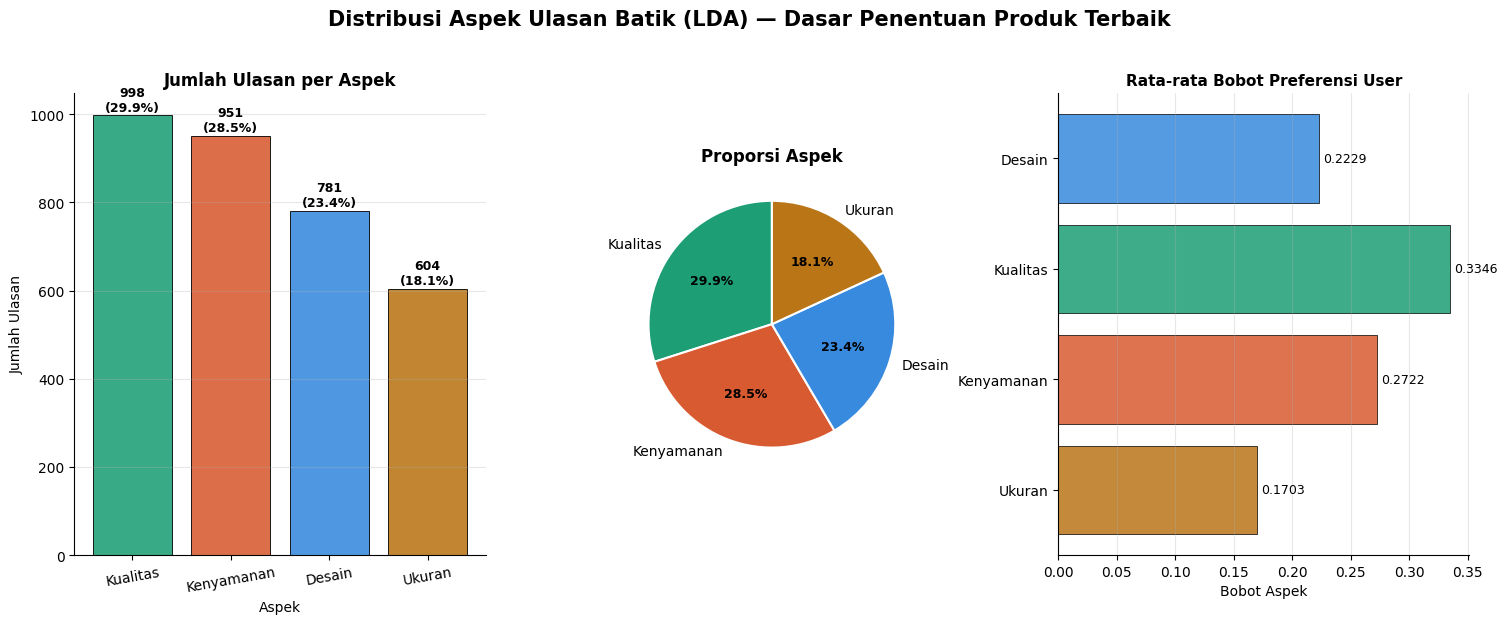

✅ Distribusi aspek EFM tersimpan: distribusi_aspek_efm_lda.png


In [115]:
# ============================================================
# 4.11.0 Distribusi Aspek — Digunakan untuk Menentukan Produk Terbaik
# ============================================================
import matplotlib.patches as mpatches

# Hitung distribusi aspek dari train_df
aspek_train = train_df['aspek_lda'] if 'aspek_lda' in train_df.columns else df_clean['aspek_lda']
aspek_valid = aspek_train[aspek_train != 'Unknown']
aspek_counts_viz = aspek_valid.value_counts()
aspek_pct_viz    = (aspek_counts_viz / aspek_counts_viz.sum() * 100).round(1)

colors_aspek_list = [ASPEK_COLORS.get(a, '#888888') for a in aspek_counts_viz.index]

fig = plt.figure(figsize=(18, 6))
fig.suptitle('Distribusi Aspek Ulasan Batik (LDA) — Dasar Penentuan Produk Terbaik',
             fontsize=15, fontweight='bold', y=1.02)

gs = fig.add_gridspec(1, 3, width_ratios=[2, 1.5, 2], wspace=0.35)

# --- 1. Bar Chart ---
ax1 = fig.add_subplot(gs[0])
bars = ax1.bar(aspek_counts_viz.index, aspek_counts_viz.values,
               color=colors_aspek_list, edgecolor='black', linewidth=0.7, alpha=0.88)
ax1.set_title('Jumlah Ulasan per Aspek', fontsize=12, fontweight='bold')
ax1.set_xlabel('Aspek', fontsize=10)
ax1.set_ylabel('Jumlah Ulasan', fontsize=10)
ax1.tick_params(axis='x', rotation=10)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)
for bar, pct in zip(bars, aspek_pct_viz.values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(aspek_counts_viz)*0.01,
             f'{int(bar.get_height())}\n({pct}%)', ha='center', fontsize=9, fontweight='bold')

# --- 2. Pie Chart ---
ax2 = fig.add_subplot(gs[1])
wedge_props = dict(edgecolor='white', linewidth=1.5)
wedges, texts, autotexts = ax2.pie(
    aspek_counts_viz.values,
    labels=aspek_counts_viz.index,
    autopct='%1.1f%%',
    colors=colors_aspek_list,
    startangle=90,
    wedgeprops=wedge_props,
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
ax2.set_title('Proporsi Aspek', fontsize=12, fontweight='bold')

# --- 3. Bobot Aspek dalam EFM (diagram batang horizontal) ---
ax3 = fig.add_subplot(gs[2])
bobot_aspek = {a: 1/len(ASPEK_FINAL) for a in ASPEK_FINAL}  # bobot seimbang
# Jika bobot_user tersedia, hitung rata-rata bobot user per aspek
try:
    bobot_avg = {a: np.mean([w.get(a, 0) for w in bobot_user.values()]) for a in ASPEK_FINAL}
    bobot_aspek = bobot_avg
    bobot_label = 'Rata-rata Bobot Preferensi User'
except Exception:
    bobot_label = 'Bobot Seimbang (1/N Aspek)'

aspek_names = list(bobot_aspek.keys())
bobot_vals  = [bobot_aspek[a] for a in aspek_names]
colors_bobot = [ASPEK_COLORS.get(a, '#888888') for a in aspek_names]

hbars = ax3.barh(aspek_names, bobot_vals, color=colors_bobot, edgecolor='black',
                  linewidth=0.6, alpha=0.85)
ax3.set_title(bobot_label, fontsize=11, fontweight='bold')
ax3.set_xlabel('Bobot Aspek', fontsize=10)
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)
ax3.spines[['top', 'right']].set_visible(False)
for hbar, val in zip(hbars, bobot_vals):
    ax3.text(hbar.get_width() + max(bobot_vals)*0.01, hbar.get_y() + hbar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

# Catatan kontribusi aspek
total_ulasan = aspek_counts_viz.sum()
print('=' * 60)
print('  DISTRIBUSI ASPEK — KONTRIBUSI PADA PENENTUAN PRODUK TERBAIK')
print('=' * 60)
for aspek in aspek_counts_viz.index:
    cnt = aspek_counts_viz[aspek]
    pct = aspek_pct_viz[aspek]
    w   = bobot_aspek.get(aspek, 0)
    print(f'  {aspek:<12}: {cnt:>5} ulasan ({pct:>5.1f}%)  |  bobot EFM: {w:.4f}')
print(f'  {"TOTAL":<12}: {total_ulasan:>5} ulasan (100.0%)')
print('=' * 60)

plt.tight_layout()
plt.savefig('distribusi_aspek_efm_lda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Distribusi aspek EFM tersimpan: distribusi_aspek_efm_lda.png')


## 4.11.1 Top-5 Produk Terbaik per Aspek

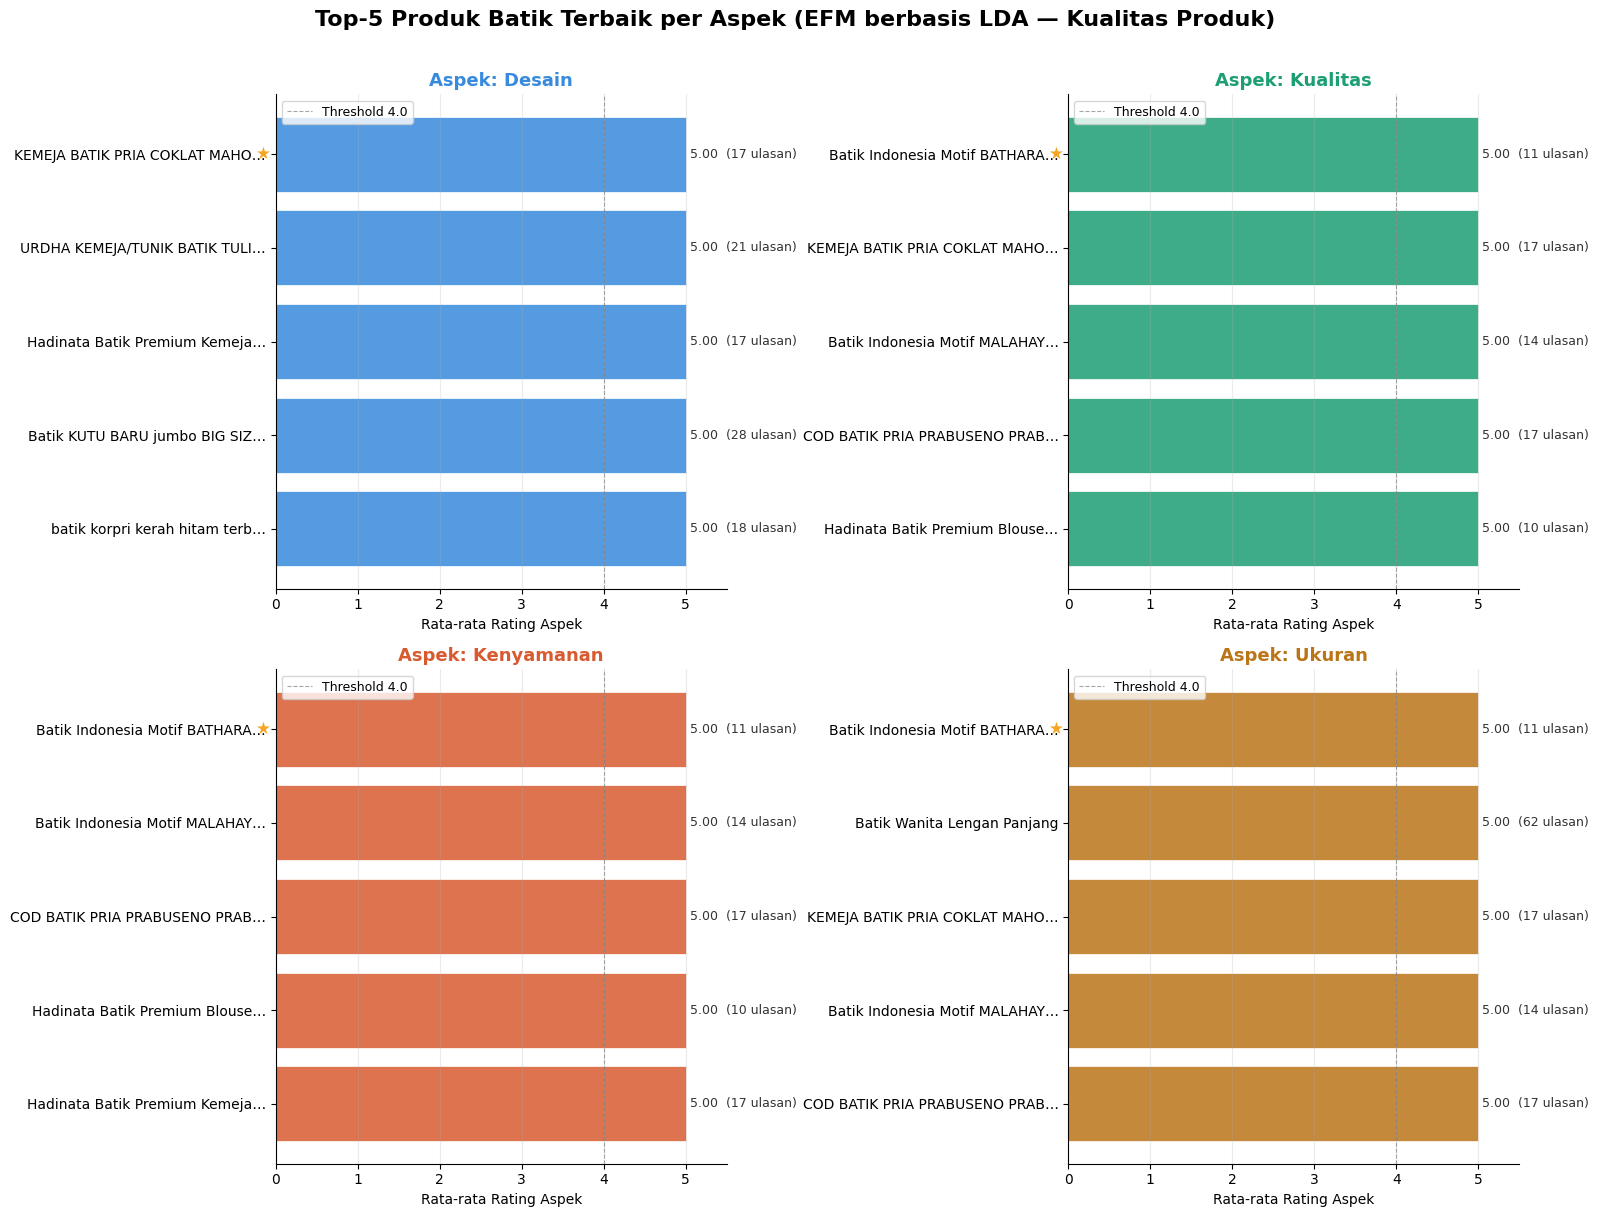

✅ Visualisasi Top-5 per Aspek (LDA) tersimpan.


In [116]:
def shorten(name, max_len=30):
    return name if len(name) <= max_len else name[:max_len-1] + '…'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Top-5 Produk Batik Terbaik per Aspek (EFM berbasis LDA — Kualitas Produk)',
             fontsize=16, fontweight='bold', y=1.01)

for ax, aspek in zip(axes.flat, ASPEK_FINAL):
    color = ASPEK_COLORS[aspek]
    top5  = df_kualitas.nlargest(TOP_K, aspek)[['Product Name', aspek, 'n_ulasan']].reset_index(drop=True)
    labels = [shorten(n) for n in top5['Product Name']]
    vals   = top5[aspek].values

    bars = ax.barh(range(TOP_K), vals, color=color, alpha=0.85, edgecolor='white', linewidth=0.6)
    ax.set_yticks(range(TOP_K))
    ax.set_yticklabels(labels, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlim(0, 5.5)
    ax.set_xlabel('Rata-rata Rating Aspek', fontsize=10)
    ax.set_title(f'Aspek: {aspek}', fontsize=13, fontweight='bold', color=color)
    ax.axvline(x=4.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Threshold 4.0')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

    for i, (bar, row) in enumerate(zip(bars, top5.itertuples())):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{getattr(row, aspek):.2f}  ({row.n_ulasan} ulasan)',
                va='center', ha='left', fontsize=9, color='#333333')
        if i == 0:
            ax.text(-0.15, bar.get_y() + bar.get_height()/2, '★',
                    va='center', ha='center', fontsize=12, color='#F5A623')

plt.tight_layout()
plt.savefig('top5_per_aspek_lda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi Top-5 per Aspek (LDA) tersimpan.')

## 4.11.2 Radar Chart — Profil Kualitas Top-5 Produk

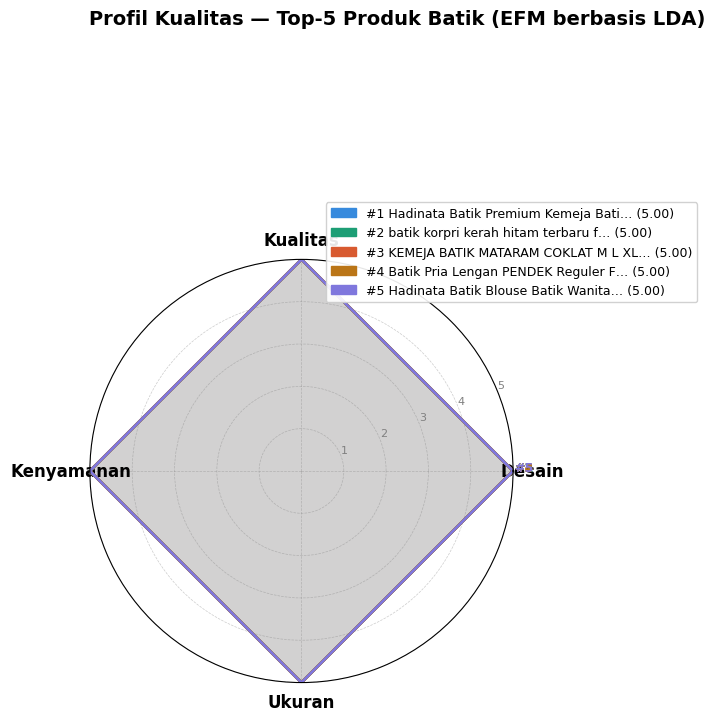

✅ Radar chart (LDA) tersimpan.


In [117]:
global_w = {a: 1/len(ASPEK_FINAL) for a in ASPEK_FINAL}
df_kualitas['skor_efm'] = df_kualitas[ASPEK_FINAL].apply(
    lambda row: sum(global_w[a] * row[a] for a in ASPEK_FINAL), axis=1
)
top5_overall = df_kualitas.nlargest(5, 'skor_efm').reset_index(drop=True)

N = len(ASPEK_FINAL)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

palette = ['#378ADD', '#1D9E75', '#D85A30', '#BA7517', '#7F77DD']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle('Profil Kualitas — Top-5 Produk Batik (EFM berbasis LDA)',
             fontsize=14, fontweight='bold', y=1.02)

for idx, prod in top5_overall.iterrows():
    vals = [prod[a] for a in ASPEK_FINAL] + [prod[ASPEK_FINAL[0]]]
    color = palette[idx]
    ax.plot(angles, vals, color=color, linewidth=2, linestyle='solid')
    ax.fill(angles, vals, color=color, alpha=0.08)
    max_idx = np.argmax([prod[a] for a in ASPEK_FINAL])
    ax.annotate(
        f'#{idx+1}',
        xy=(angles[max_idx], vals[max_idx]),
        xytext=(angles[max_idx], vals[max_idx] + 0.25),
        fontsize=9, color=color, fontweight='bold', ha='center'
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(ASPEK_FINAL, fontsize=12, fontweight='bold')
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1','2','3','4','5'], fontsize=8, color='gray')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)

handles = [
    mpatches.Patch(color=palette[i],
        label=f'#{i+1} {shorten(top5_overall.loc[i,"Product Name"], 35)} ({top5_overall.loc[i,"skor_efm"]:.2f})')
    for i in range(5)
]
ax.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.45, 1.15),
          fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('radar_top5_lda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Radar chart (LDA) tersimpan.')

## 4.11.3 Heatmap Kualitas Produk per Aspek (Top-20)

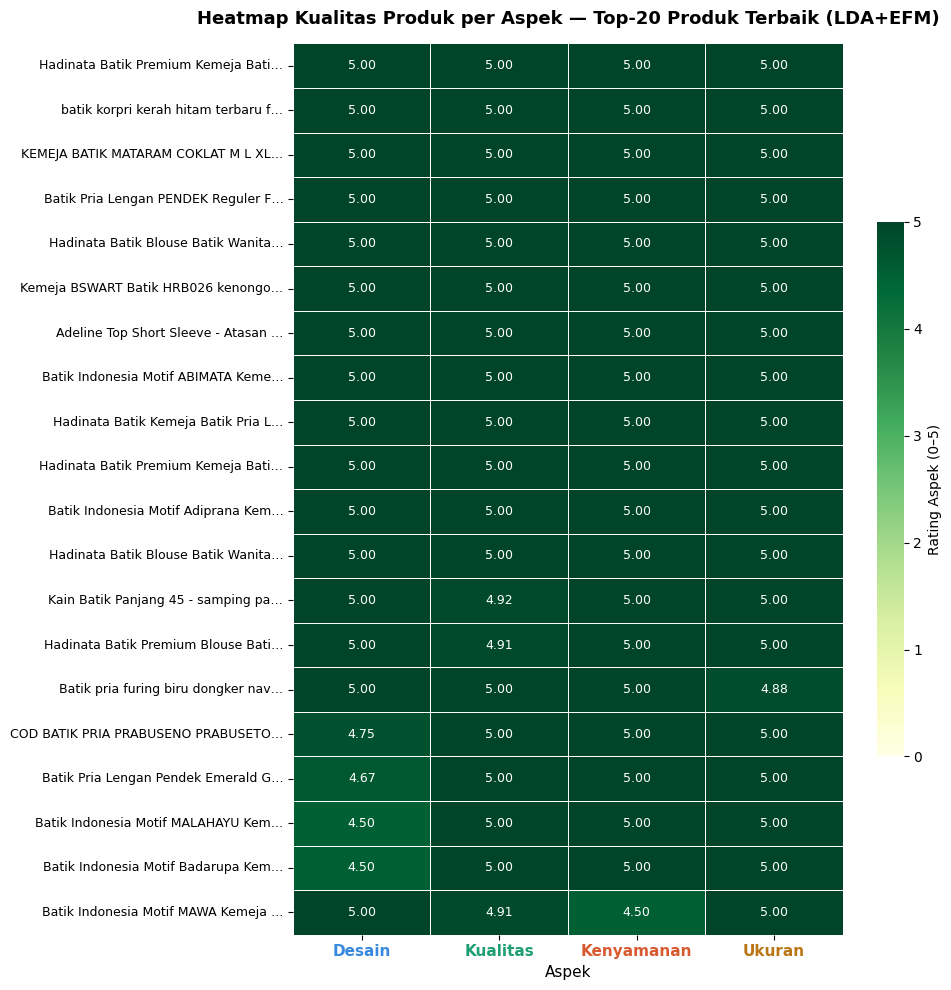

✅ Heatmap (LDA) tersimpan.


In [118]:
top20 = df_kualitas.nlargest(20, 'skor_efm')[['Product Name'] + ASPEK_FINAL].copy()
top20['Product Name'] = top20['Product Name'].apply(lambda x: shorten(x, 35))
top20 = top20.set_index('Product Name')

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    top20,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cmap='YlGn', vmin=0, vmax=5,
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Rating Aspek (0–5)', 'shrink': 0.6},
    ax=ax
)
ax.set_title('Heatmap Kualitas Produk per Aspek — Top-20 Produk Terbaik (LDA+EFM)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Aspek', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=11, rotation=0)
ax.tick_params(axis='y', labelsize=9)

for i, aspek in enumerate(ASPEK_FINAL):
    ax.get_xticklabels()[i].set_color(ASPEK_COLORS[aspek])
    ax.get_xticklabels()[i].set_fontweight('bold')

plt.tight_layout()
plt.savefig('heatmap_kualitas_lda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap (LDA) tersimpan.')

## 4.11.4 Ringkasan Produk Terbaik per Aspek (Tabel)

In [119]:
print('=' * 75)
print(f'  RINGKASAN PRODUK TERBAIK PER ASPEK (TOP-{TOP_K}) — LDA + EFM')
print('=' * 75)

for aspek in ASPEK_FINAL:
    top = df_kualitas.nlargest(TOP_K, aspek)[['Product Name', aspek, 'n_ulasan']].reset_index(drop=True)
    print(f'\n  Aspek: {aspek}')
    print(f'  {"Rank":<5} {"Nama Produk":<45} {aspek:>8}  {"Ulasan":>8}')
    print('  ' + '-' * 68)
    for i, row in top.iterrows():
        medal = ['★', '✦', '◆', '▲', '●'][i]
        print(f'  {medal} #{i+1:<3} {shorten(row["Product Name"],44):<45} {row[aspek]:>8.2f}  {row["n_ulasan"]:>8}')

print()
print('=' * 75)
print('  TOP-5 PRODUK TERBAIK KESELURUHAN (Bobot Seimbang) — LDA + EFM')
print('=' * 75)
print(f'  {"Rank":<5} {"Nama Produk":<45} {"Skor EFM":>10}  {"Ulasan":>8}')
print('  ' + '-' * 70)
for i, row in top5_overall.iterrows():
    medal = ['★', '✦', '◆', '▲', '●'][i]
    print(f'  {medal} #{i+1:<3} {shorten(row["Product Name"],44):<45} {row["skor_efm"]:>10.4f}  {row["n_ulasan"]:>8}')
print('=' * 75)
print('=' * 75)
print('  DISTRIBUSI ASPEK — RINGKASAN KONTRIBUSI')
print('=' * 75)
aspek_all = df_clean['aspek_lda'] if 'aspek_lda' in df_clean.columns else pd.Series()
for aspek in ASPEK_FINAL:
    cnt = (aspek_all == aspek).sum()
    pct = cnt / len(aspek_all) * 100 if len(aspek_all) > 0 else 0
    top_prod = df_kualitas.nlargest(1, aspek)['Product Name'].values[0] if len(df_kualitas) > 0 else '-'
    print(f'  {aspek:<12}: {cnt:>5} ulasan ({pct:.1f}%)  →  Produk terbaik: {shorten(top_prod, 35)}')
print('=' * 75)
print('✅ Seluruh analisis LDA + EFM selesai!')


  RINGKASAN PRODUK TERBAIK PER ASPEK (TOP-5) — LDA + EFM

  Aspek: Desain
  Rank  Nama Produk                                     Desain    Ulasan
  --------------------------------------------------------------------
  ★ #1   KEMEJA BATIK PRIA COKLAT MAHOGANY LENGAN PA…      5.00        17
  ✦ #2   URDHA KEMEJA/TUNIK BATIK TULIS PREMIUM - Ba…      5.00        21
  ◆ #3   Hadinata Batik Premium Kemeja Batik Pria Le…      5.00        17
  ▲ #4   Batik KUTU BARU jumbo BIG SIZE JUMBO XXL XX…      5.00        28
  ● #5   batik korpri kerah hitam terbaru full furin…      5.00        18

  Aspek: Kualitas
  Rank  Nama Produk                                   Kualitas    Ulasan
  --------------------------------------------------------------------
  ★ #1   Batik Indonesia Motif BATHARA Kemeja Batik …      5.00        11
  ✦ #2   KEMEJA BATIK PRIA COKLAT MAHOGANY LENGAN PA…      5.00        17
  ◆ #3   Batik Indonesia Motif MALAHAYU Kemeja Batik…      5.00        14
  ▲ #4   COD BATIK PRIA PRA

---
# 4.12 Visualisasi Tambahan — Analisis Mendalam LDA

Bagian ini menambahkan 5 visualisasi ekstra:
1. **Distribusi Probabilitas Topik per Dokumen** (θ) — violin & bar
2. **Word Cloud per Topik LDA** — satu cloud per topik
3. **Confusion Matrix** — aspek_lda vs aspek_keyword
4. **Heatmap θ per Aspek** — konsistensi topik dengan aspek
5. **Elbow Method** — perplexity & log-likelihood vs K

## 4.12.1 Distribusi Probabilitas Topik per Dokumen (θ)

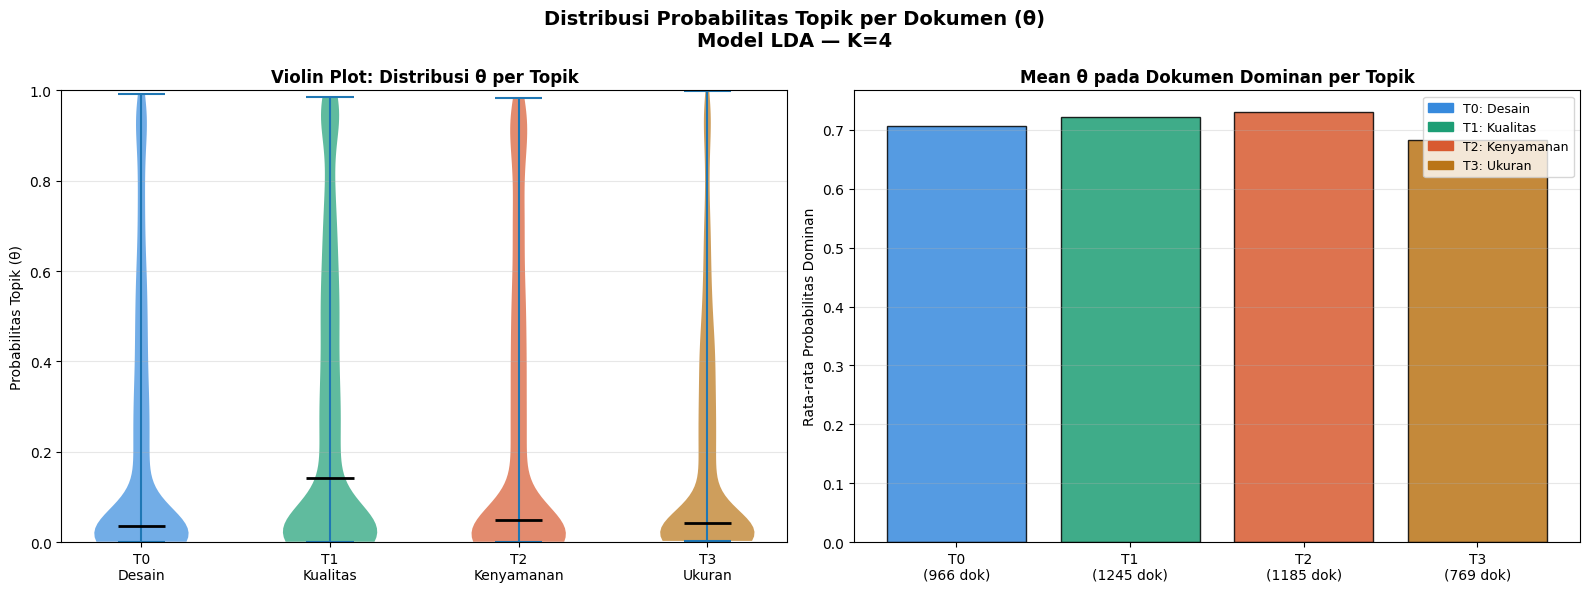

✅ Visualisasi probabilitas topik tersimpan.


In [120]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# doc_topic_dist harus sudah tersedia dari Section 4.9.8
# Jika belum, hitung ulang:
# doc_topic_dist = lda_model.transform(dtm)

ASPEK_COLORS = {
    'Desain':'#378ADD','Kualitas':'#1D9E75','Kenyamanan':'#D85A30','Ukuran':'#BA7517'
}
colors_t = [ASPEK_COLORS[topic_aspek_map[i]] for i in range(N_TOPICS)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribusi Probabilitas Topik per Dokumen (θ)\nModel LDA — K=4',
             fontsize=14, fontweight='bold')

# Violin plot
parts = axes[0].violinplot(
    [doc_topic_dist[:, i] for i in range(N_TOPICS)],
    positions=range(N_TOPICS), showmedians=True, showextrema=True
)
for pc, col in zip(parts['bodies'], colors_t):
    pc.set_facecolor(col); pc.set_alpha(0.7)
parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
axes[0].set_xticks(range(N_TOPICS))
axes[0].set_xticklabels([f'T{i}\n{topic_aspek_map[i]}' for i in range(N_TOPICS)], fontsize=10)
axes[0].set_ylabel('Probabilitas Topik (θ)')
axes[0].set_title('Violin Plot: Distribusi θ per Topik', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1)

# Bar: mean probabilitas topik dominan
dominant = doc_topic_dist.argmax(axis=1)
counts = pd.Series(dominant).value_counts().sort_index()
for tid in range(N_TOPICS):
    mask_dom = dominant == tid
    if mask_dom.sum() == 0: continue
    mean_probs = doc_topic_dist[mask_dom].mean(axis=0)
    axes[1].bar(tid, mean_probs[tid], color=colors_t[tid], alpha=0.85, edgecolor='black')

axes[1].set_xticks(range(N_TOPICS))
axes[1].set_xticklabels([f'T{i}\n({counts.get(i,0)} dok)' for i in range(N_TOPICS)], fontsize=10)
axes[1].set_ylabel('Rata-rata Probabilitas Dominan')
axes[1].set_title('Mean θ pada Dokumen Dominan per Topik', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
handles = [mpatches.Patch(color=colors_t[i], label=f'T{i}: {topic_aspek_map[i]}')
           for i in range(N_TOPICS)]
axes[1].legend(handles=handles, fontsize=9)

plt.tight_layout()
plt.savefig('viz1_distribusi_probabilitas_topik.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi probabilitas topik tersimpan.')

## 4.12.2 Word Cloud per Topik LDA

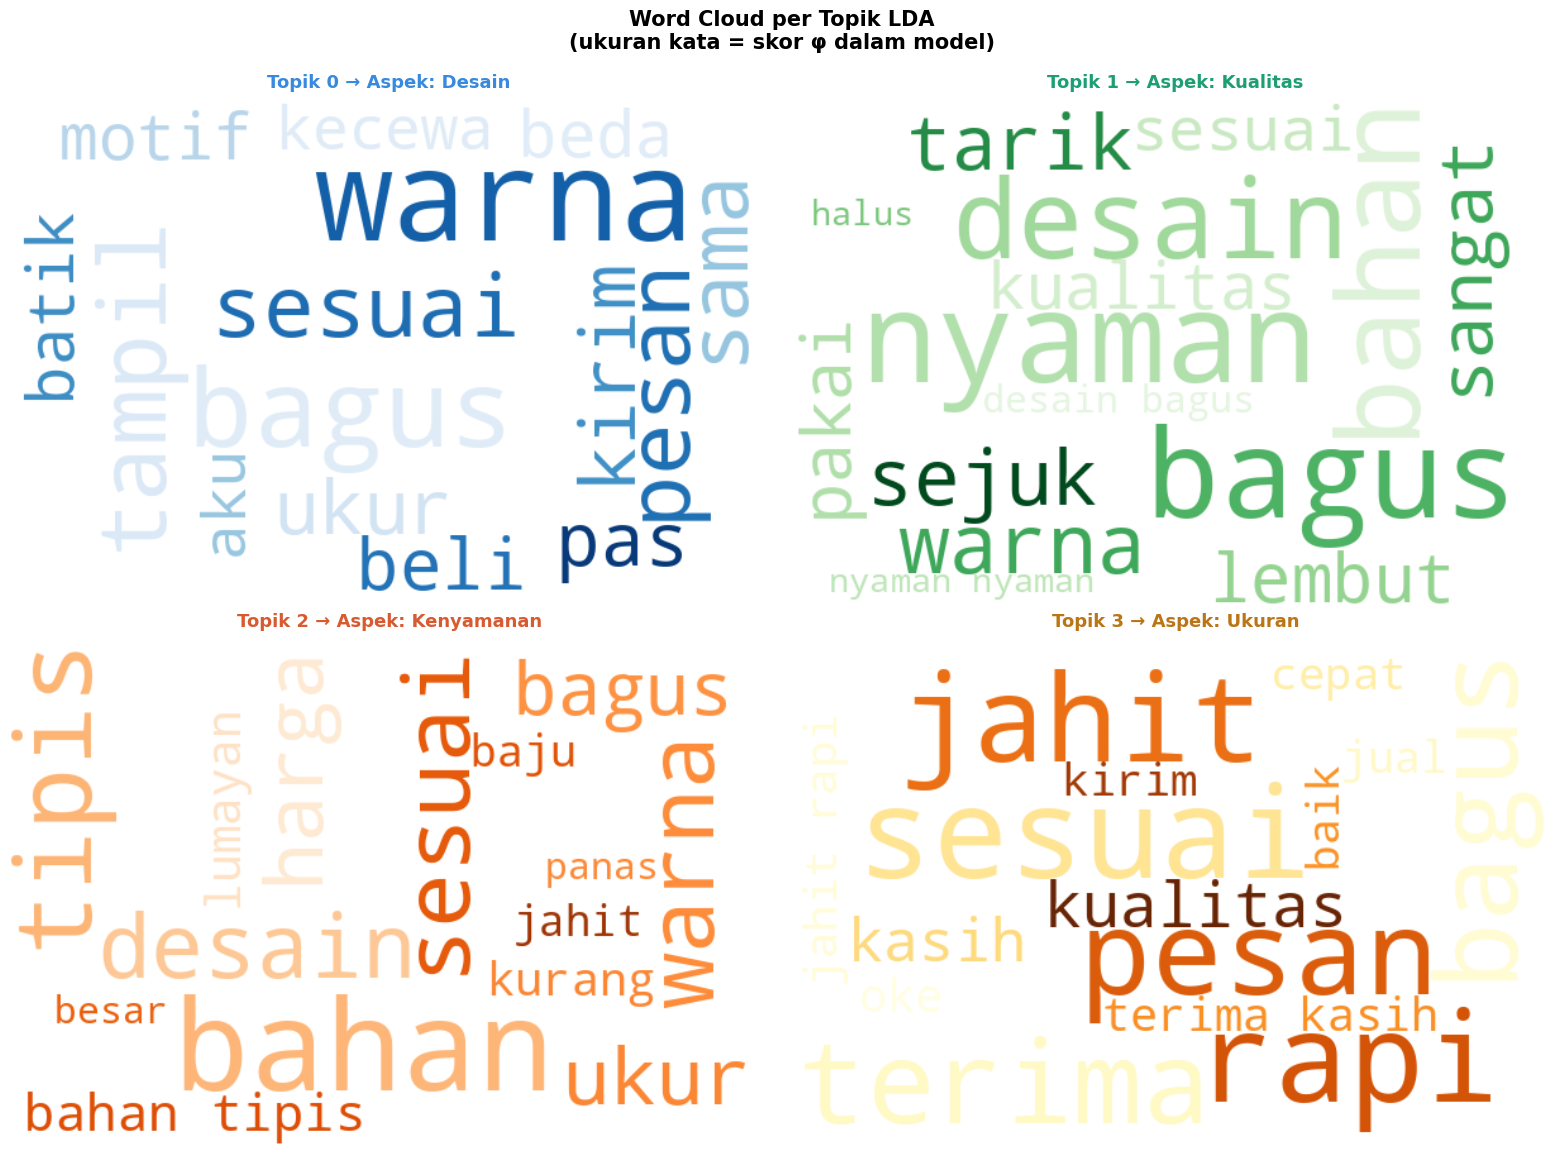

✅ Word Cloud per Topik LDA tersimpan.


In [121]:
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Word Cloud per Topik LDA\n(ukuran kata = skor φ dalam model)',
             fontsize=15, fontweight='bold')

cmaps = ['Blues', 'Greens', 'Oranges', 'YlOrBr']
for idx, ax in enumerate(axes.flat):
    aspek = topic_aspek_map[idx]
    word_freq = {w: float(s) for w, s in lda_topics[idx][:50]}
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=cmaps[idx],
        max_words=60,
        collocations=False,
        prefer_horizontal=0.8,
        max_font_size=100,
    )
    wc.generate_from_frequencies(word_freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Topik {idx} → Aspek: {aspek}',
                 fontsize=13, fontweight='bold', color=ASPEK_COLORS[aspek], pad=10)
    for spine in ax.spines.values():
        spine.set_edgecolor(ASPEK_COLORS[aspek])
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.tight_layout(pad=2)
plt.savefig('viz2_wordcloud_per_topik_lda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Word Cloud per Topik LDA tersimpan.')

## 4.12.3 Confusion Matrix — Aspek LDA vs Aspek Keyword

Membandingkan hasil penugasan aspek dari dua metode:
- **Baris (Y)** = `aspek_keyword` — penugasan berbasis keyword matching (referensi)
- **Kolom (X)** = `aspek_lda` — penugasan berbasis LDA (prediksi)

Diagonal tinggi = kedua metode sepakat. Off-diagonal = perbedaan interpretasi.

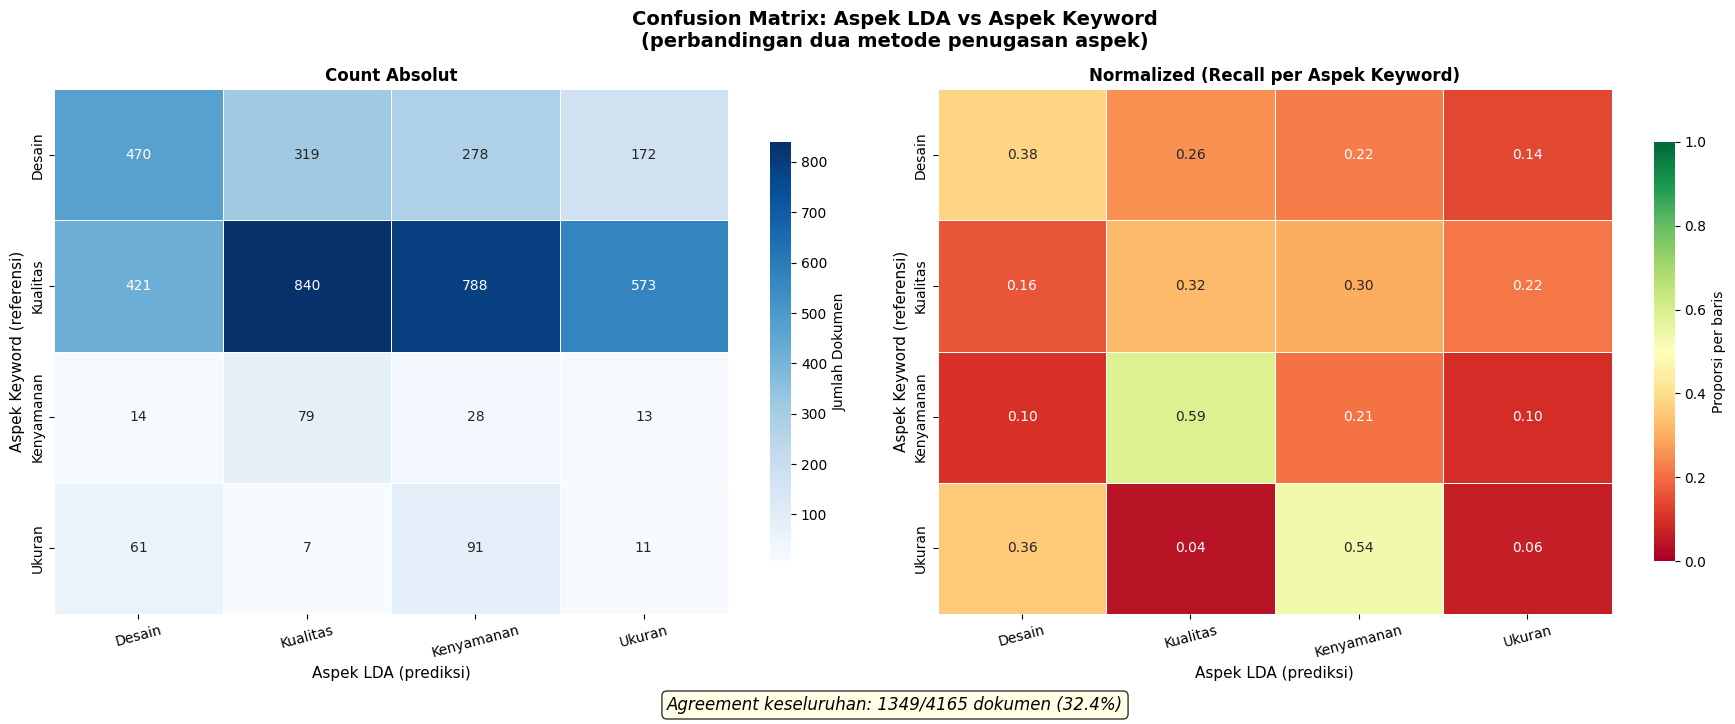

Agreement: 1349/4165 = 32.4%
✅ Confusion Matrix tersimpan.


In [122]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

ASPEK_FINAL = ['Desain', 'Kualitas', 'Kenyamanan', 'Ukuran']

df_both = df_clean[
    df_clean['aspek_lda'].isin(ASPEK_FINAL) &
    df_clean['aspek_keyword'].isin(ASPEK_FINAL)
].copy()

cm = confusion_matrix(df_both['aspek_keyword'], df_both['aspek_lda'], labels=ASPEK_FINAL)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Confusion Matrix: Aspek LDA vs Aspek Keyword\n'
             '(perbandingan dua metode penugasan aspek)',
             fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ASPEK_FINAL, yticklabels=ASPEK_FINAL,
            linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Jumlah Dokumen', 'shrink': 0.8})
axes[0].set_title('Count Absolut', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Aspek LDA (prediksi)', fontsize=11)
axes[0].set_ylabel('Aspek Keyword (referensi)', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=ASPEK_FINAL, yticklabels=ASPEK_FINAL,
            vmin=0, vmax=1, linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Proporsi per baris', 'shrink': 0.8})
axes[1].set_title('Normalized (Recall per Aspek Keyword)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Aspek LDA (prediksi)', fontsize=11)
axes[1].set_ylabel('Aspek Keyword (referensi)', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)

n_agree  = int(np.trace(cm))
n_total  = int(cm.sum())
pct      = n_agree / n_total * 100
fig.text(0.5, -0.02,
         f'Agreement keseluruhan: {n_agree}/{n_total} dokumen ({pct:.1f}%)',
         ha='center', fontsize=12, fontstyle='italic',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('viz3_confusion_matrix_aspek.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Agreement: {n_agree}/{n_total} = {pct:.1f}%')
print('✅ Confusion Matrix tersimpan.')

## 4.12.4 Heatmap θ per Aspek

Setiap baris = kelompok dokumen yg di-assign ke aspek tertentu.
Nilai = rata-rata probabilitas topik dari dokumen di kelompok itu.
Diagonal tinggi menunjukkan topik konsisten dengan aspek.

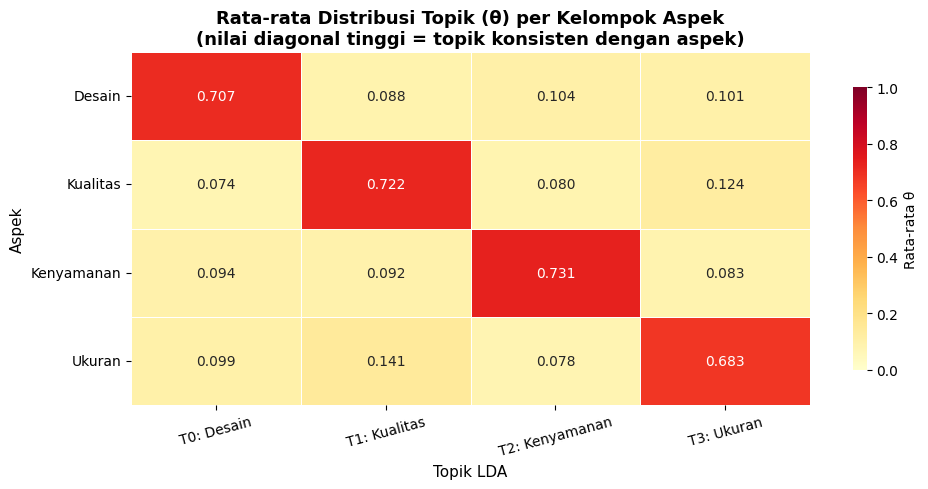

✅ Heatmap θ tersimpan.


In [123]:
aspek_topic_matrix = np.zeros((len(ASPEK_FINAL), N_TOPICS))
for ai, aspek in enumerate(ASPEK_FINAL):
    mask = df_clean.loc[idx_valid, 'aspek_lda'] == aspek
    if mask.sum() == 0: continue
    aspek_probs = doc_topic_dist[mask.values]
    aspek_topic_matrix[ai] = aspek_probs.mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
col_labels = [f'T{i}: {topic_aspek_map[i]}' for i in range(N_TOPICS)]
sns.heatmap(aspek_topic_matrix,
            annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=col_labels, yticklabels=ASPEK_FINAL,
            vmin=0, vmax=1, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Rata-rata θ', 'shrink': 0.8}, ax=ax)
ax.set_title('Rata-rata Distribusi Topik (θ) per Kelompok Aspek\n'
             '(nilai diagonal tinggi = topik konsisten dengan aspek)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Topik LDA', fontsize=11)
ax.set_ylabel('Aspek', fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('viz4_heatmap_theta_per_aspek.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap θ tersimpan.')

## 4.12.5 Elbow Method — Perplexity & Log-Likelihood vs K

⏳ Menghitung elbow (K=2..9)...
  K=2: Perplexity=886.1  LogLik=-624649.1
  K=3: Perplexity=854.5  LogLik=-621304.1
  K=4: Perplexity=859.8  LogLik=-621868.7
  K=5: Perplexity=870.3  LogLik=-622991.3
  K=6: Perplexity=876.2  LogLik=-623615.6
  K=7: Perplexity=897.8  LogLik=-625849.4
  K=8: Perplexity=906.8  LogLik=-626771.9
  K=9: Perplexity=910.7  LogLik=-627162.3


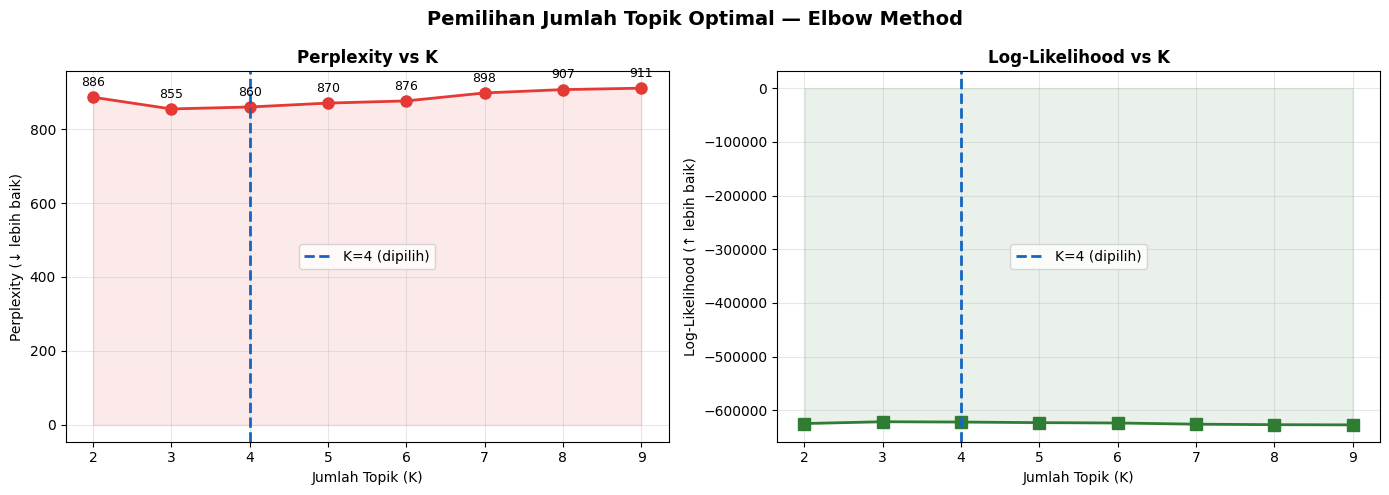

✅ Elbow chart tersimpan.


In [124]:
from sklearn.decomposition import LatentDirichletAllocation

k_range = range(2, 10)
perplexities, log_likes = [], []
print('⏳ Menghitung elbow (K=2..9)...')
for k in k_range:
    m = LatentDirichletAllocation(
        n_components=k, max_iter=30,
        learning_method='batch', random_state=42
    )
    m.fit(dtm)
    perplexities.append(m.perplexity(dtm))
    log_likes.append(m.score(dtm))
    print(f'  K={k}: Perplexity={m.perplexity(dtm):.1f}  LogLik={m.score(dtm):.1f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pemilihan Jumlah Topik Optimal — Elbow Method', fontsize=14, fontweight='bold')

axes[0].plot(list(k_range), perplexities, 'o-', color='#e53935', linewidth=2, markersize=8)
axes[0].axvline(x=4, color='#1565c0', linestyle='--', linewidth=2, label='K=4 (dipilih)')
axes[0].fill_between(list(k_range), perplexities, alpha=0.1, color='#e53935')
axes[0].set_title('Perplexity vs K', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Topik (K)')
axes[0].set_ylabel('Perplexity (↓ lebih baik)')
axes[0].legend(); axes[0].grid(alpha=0.3)
for k, p in zip(k_range, perplexities):
    axes[0].annotate(f'{p:.0f}', (k, p), textcoords='offset points',
                     xytext=(0,8), ha='center', fontsize=9)

axes[1].plot(list(k_range), log_likes, 's-', color='#2e7d32', linewidth=2, markersize=8)
axes[1].axvline(x=4, color='#1565c0', linestyle='--', linewidth=2, label='K=4 (dipilih)')
axes[1].fill_between(list(k_range), log_likes, alpha=0.1, color='#2e7d32')
axes[1].set_title('Log-Likelihood vs K', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Topik (K)')
axes[1].set_ylabel('Log-Likelihood (↑ lebih baik)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('viz5_elbow_lda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Elbow chart tersimpan.')